<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

##Drive Mount##

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).

In [1]:
from google.colab import drive

# Correct mount point to a directory
drive.mount('/content/drive')

# After mounting, specify the path to your 'Churn.csv' file
import pandas as pd

# Assuming 'Churn.csv' is in the main Google Drive folder
file_path = '/content/drive/My Drive/Churn.csv'  # Adjust if the file is in a different folder within Google Drive
df = pd.read_csv(file_path)

Mounted at /content/drive


##Import Libraries##

In [2]:
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Library to split data
from sklearn.model_selection import train_test_split
# library to import to standardize the data
from sklearn.preprocessing import StandardScaler

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#To import different metrics
from sklearn import metrics
from sklearn.metrics import explained_variance_score, mean_squared_error, r2_score, mean_absolute_error

#Importing classback API
from keras import callbacks

# Importing tensorflow library
import tensorflow as tf

# importing different functions to build models
from tensorflow.keras.layers import Dense, Dropout,InputLayer
from tensorflow.keras.models import Sequential

# Importing Batch Normalization
from keras.layers import BatchNormalization

# Importing backend
from tensorflow.keras import backend

# Importing shffule
from random import shuffle
from keras.callbacks import ModelCheckpoint

# Importing optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD

# Library to avoid the warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import drive to access the files on My Drive
from google.colab import drive
drive.mount('/content/drive/')
import pandas as pd
# Save an object to Google Drive
# Load the dataset into the `Churn` DataFrame
Churn = pd.read_csv('/content/drive/MyDrive/Churn.csv')
import pickle
with open('/content/Churn.csv', 'wb') as f:
    pickle.dump(Churn, f)
# Reloading the object
with open('/content/Churn.csv', 'rb') as f:
    df2 = pickle.load(f)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


##Data Preparation##

In [11]:
# Display 5 sample rows
Churn.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7983,7984,15628272,Singh,774,France,Female,36,9,114997.42,1,1,0,75304.09,0
8952,8953,15713975,Gibson,565,Germany,Female,47,10,139756.12,1,1,0,165849.49,1
7470,7471,15602456,Afanasyev,850,Germany,Female,47,4,99219.47,2,1,1,122141.13,0
3571,3572,15790336,Tokareva,664,Germany,Male,36,6,71142.77,2,1,0,122433.09,0
841,842,15737792,Abbie,818,France,Female,31,1,186796.37,1,0,0,178252.63,0


In [12]:
#create a copy of the data
df = Churn.copy()

In [13]:
#drop the first 2 columns
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)
#display the data frane columns to confirm the drop command wss successful
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

It is observed that the first two columns 'RowNumber' and 'CustomerId' are unique for evry customer, hence they do not count as good predictors for our classification problem. The Surname is a variable that is common between customers just by chance and is not considered a valuable predictor as well. Therefore, those three columns need to be dropped.

In [14]:
#check if the dataset has null values
round(df.isnull().sum() / df.isnull().count() * 100, 2)
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [15]:
#check if the dataset has duplicated values
df.duplicated().sum()

0

In [16]:
#display the data types of all variables
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [17]:
#Derive the 5 point summary of the data
df.describe(include='all')

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


There are two categorical variables:

<ul><li>Geography: Contains 3 unique values, with "France" being the most common, representing 50% of the customers.</ul>
<ul><li>Gender: Includes 2 unique values, with "Male" being the most frequent.
Additional categorical indicators:</ul>

<ul><li>HasCrCard: 50% of customers hold a credit card.</ul>
<ul><li>IsActiveMember: 50% of customers are active members.</ul>
<ul><li>Exited: This is the target variable, with at least 75% of customers remaining with the bank.</ul>

<ul>The remaining five variables are numerical:</ul>

<ul><li>CreditScore: Normally distributed, ranging from 350 to 850, with an average of 650.</ul>
<ul><li>Age: Right-skewed, with values from 18 to 850 and a mean of 92.</ul>
<ul><li>Tenure: Normally distributed, with values from 0 to 850 and an average of 10.</ul>
<ul><li>Balance: Left-skewed, ranging from 0 to 250,898, and an average of 97,198.</ul>
<ul><li>EstimatedSalary: Left-skewed, with values from 11.58 to 199,992 and a mean of 100,193.</ul>
<ul>These observations will be validated through Exploratory Data Analysis (EDA).</ul>




##Exploratory Data Analysis##

<b>Exploratory Data Analysis</b>

1. Univariate Analysis</br>

EDA For the numerical variables
We will create a function to plot the histogram and box plot for all variables (note that all variables are numerical)

In [18]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, discrete=True
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

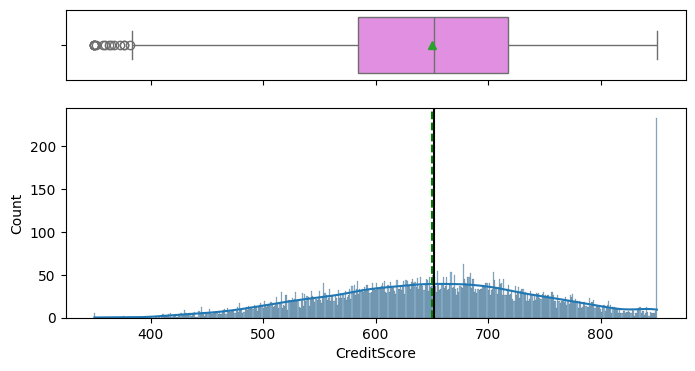

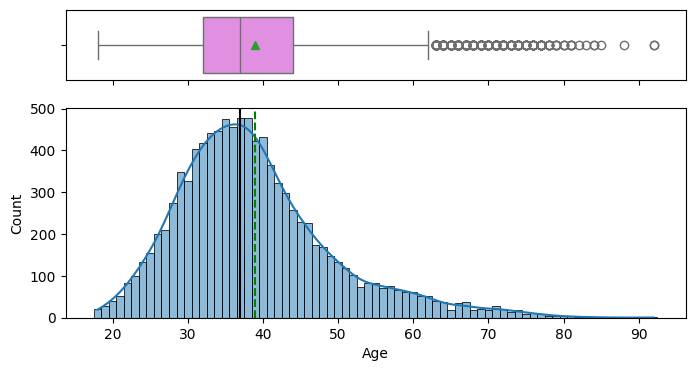

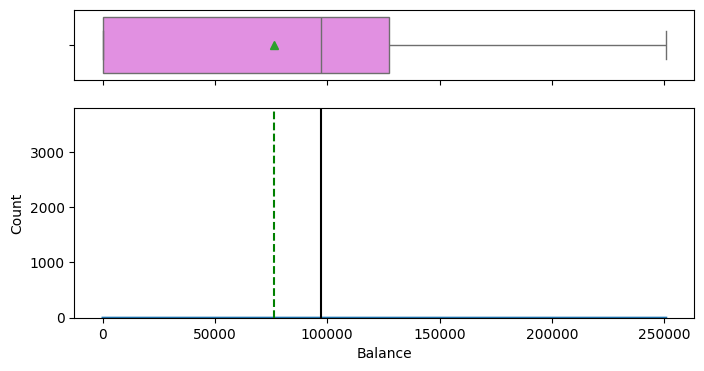

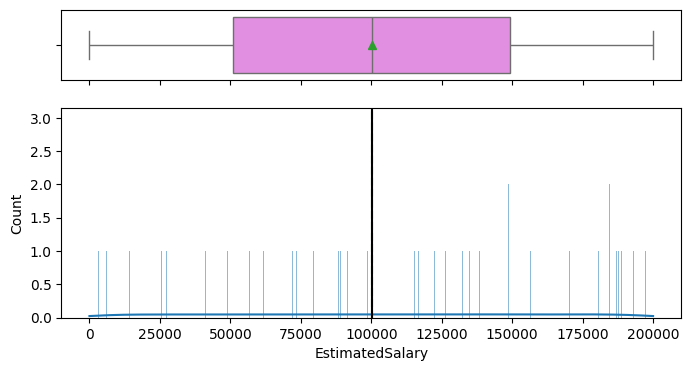

In [19]:
# create a list of numerical columns
numerical = ['CreditScore', 'Age', 'Balance','EstimatedSalary']

# ploting the numerical variables
for i in numerical:
    histogram_boxplot(df, i, kde=True, figsize=(8, 4))

<b>Observations</b><br>

<ul><li>Credit Score: The box plot indicates that the mean and median are aligned, though some outliers appear beyond the left whisker. This raises the question of whether these outliers represent customers who leave the bank, which will be explored in the bivariate analysis. The outliers are consistent with the dataset and don’t require removal.</ul>

<ul><li>Age: The distribution is right-skewed, with several outliers beyond the right whisker. These outliers are also consistent with the data and do not need to be removed.</ul>

<ul><li>Balance: The box plot shows a right-skewed distribution with no outliers. However, the histogram lacks visual clarity, so it will be re-plotted separately for more detailed analysis.</ul>

<ul><li>Estimated Salary: The box plot suggests an almost perfect normal distribution, with mean and median alignment and whiskers of roughly equal length. Since the histogram is not visually clear, it will be re-plotted on a logarithmic scale for better insight.</ul>

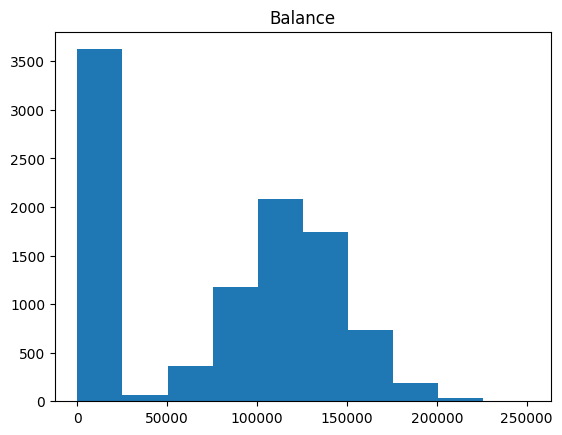

In [20]:
#plotting the data on a logarithmic scale
plt.hist(df['Balance']);
plt.title('Balance');

The balance histogram is right skewed and shows a significant number of customers (approx. 3500) with 0 balance. The remaining customers show adopt an almost normally distributed balance values. This indicates there are two different customer clusters at least. It is interesting to study further how these cluster vary with respect to our target variable in the bivariate analysis.

Estinated Salary distribution on a logarithmic scale:

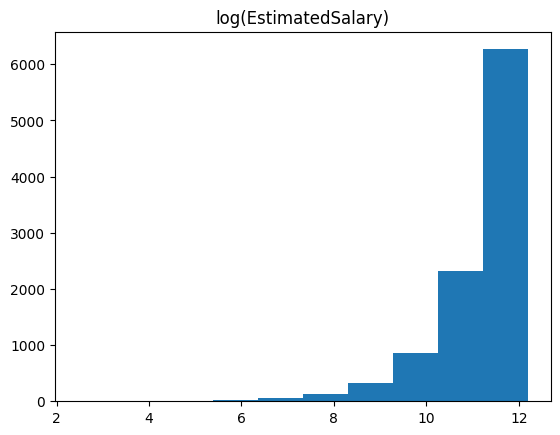

In [21]:
#plotting the data on a logarithmic scale
plt.hist(np.log(df['EstimatedSalary']));
plt.title('log(EstimatedSalary)');

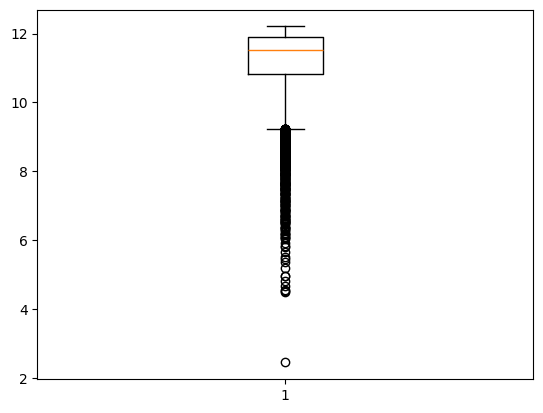

In [22]:
plt.boxplot(np.log(df['EstimatedSalary']));

On a logarithmic scale, the Estimated Salary is heavily left skewed with a high number of outliers beyond the left skewer. The outliers still seem consistent with the reality situation as a number of customers can be of high age and retired with no income salary or non-working customers.

<b>EDA For the categorical variables</b><br>
We will create a function to plot labelled barplots for all variables (note that all variables are categorical)

In [23]:
# funtcion to plot labelled barplot
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

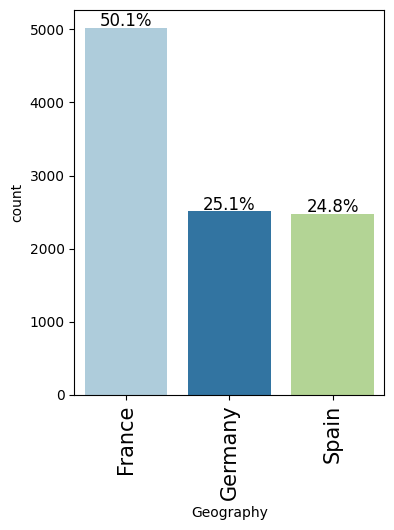

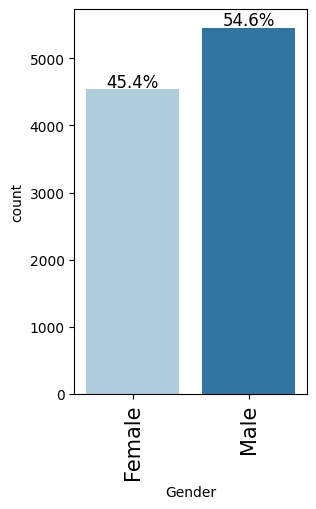

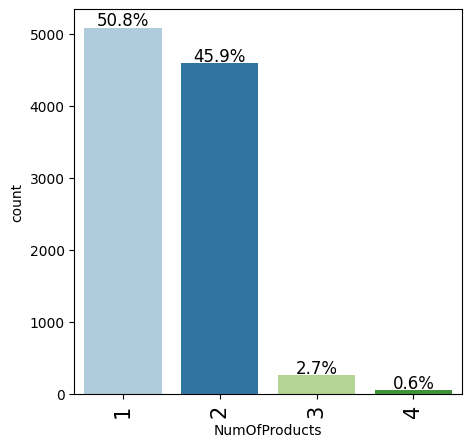

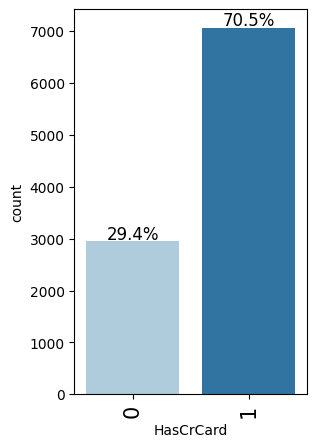

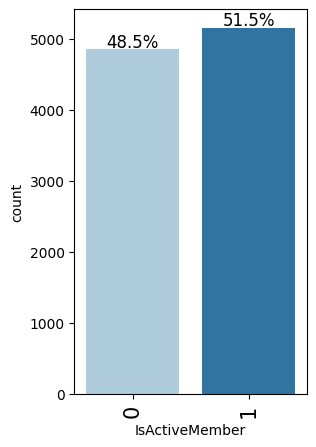

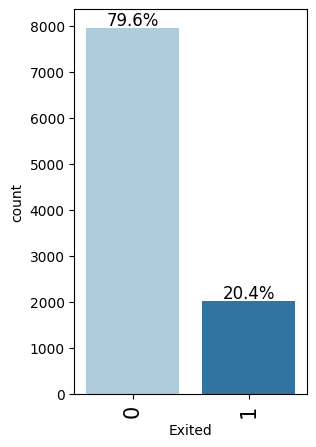

In [24]:
# create a list of categorical columns
categorical = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember','Exited']
# ploting the categorical variables
for i in categorical:
    labeled_barplot(df, i, perc=True)

<b>Observations</b><br>
<ul><li>Geography: 50% of customers are from France, 25% from Germany, and 25% from Spain.</ul></li>

<ul><li>Gender: Approximately 55% of customers are male, with the remainder female.</ul></li>

<ul><li>NumOfProducts: Half of the customers use only one product, around 46% use two products, and the remaining 3.3% use three to four products.</ul></li>

<ul><li>HasCrCard: Most customers (70%) have credit cards.</ul></li>

<ul><li>IsActiveMember: Nearly half of the customers are active members, with a slight majority being active.</ul></li>

<ul><li>Exited: Around 20% of customers have exited, while 80% have not. This indicates an imbalance in the target</ul></li>

<b>2. Bivariate analysis</b><br><br>
<ul><li>Use appropriate visualizations to identify the patterns and insights - Any other exploratory deep dive<br></ul></li>
<ul><li>Start by plotting the pair plot and heatmap to observe if there are any correlations between variables and/or clear clusterring.</ul></li>

<Figure size 1500x1500 with 0 Axes>

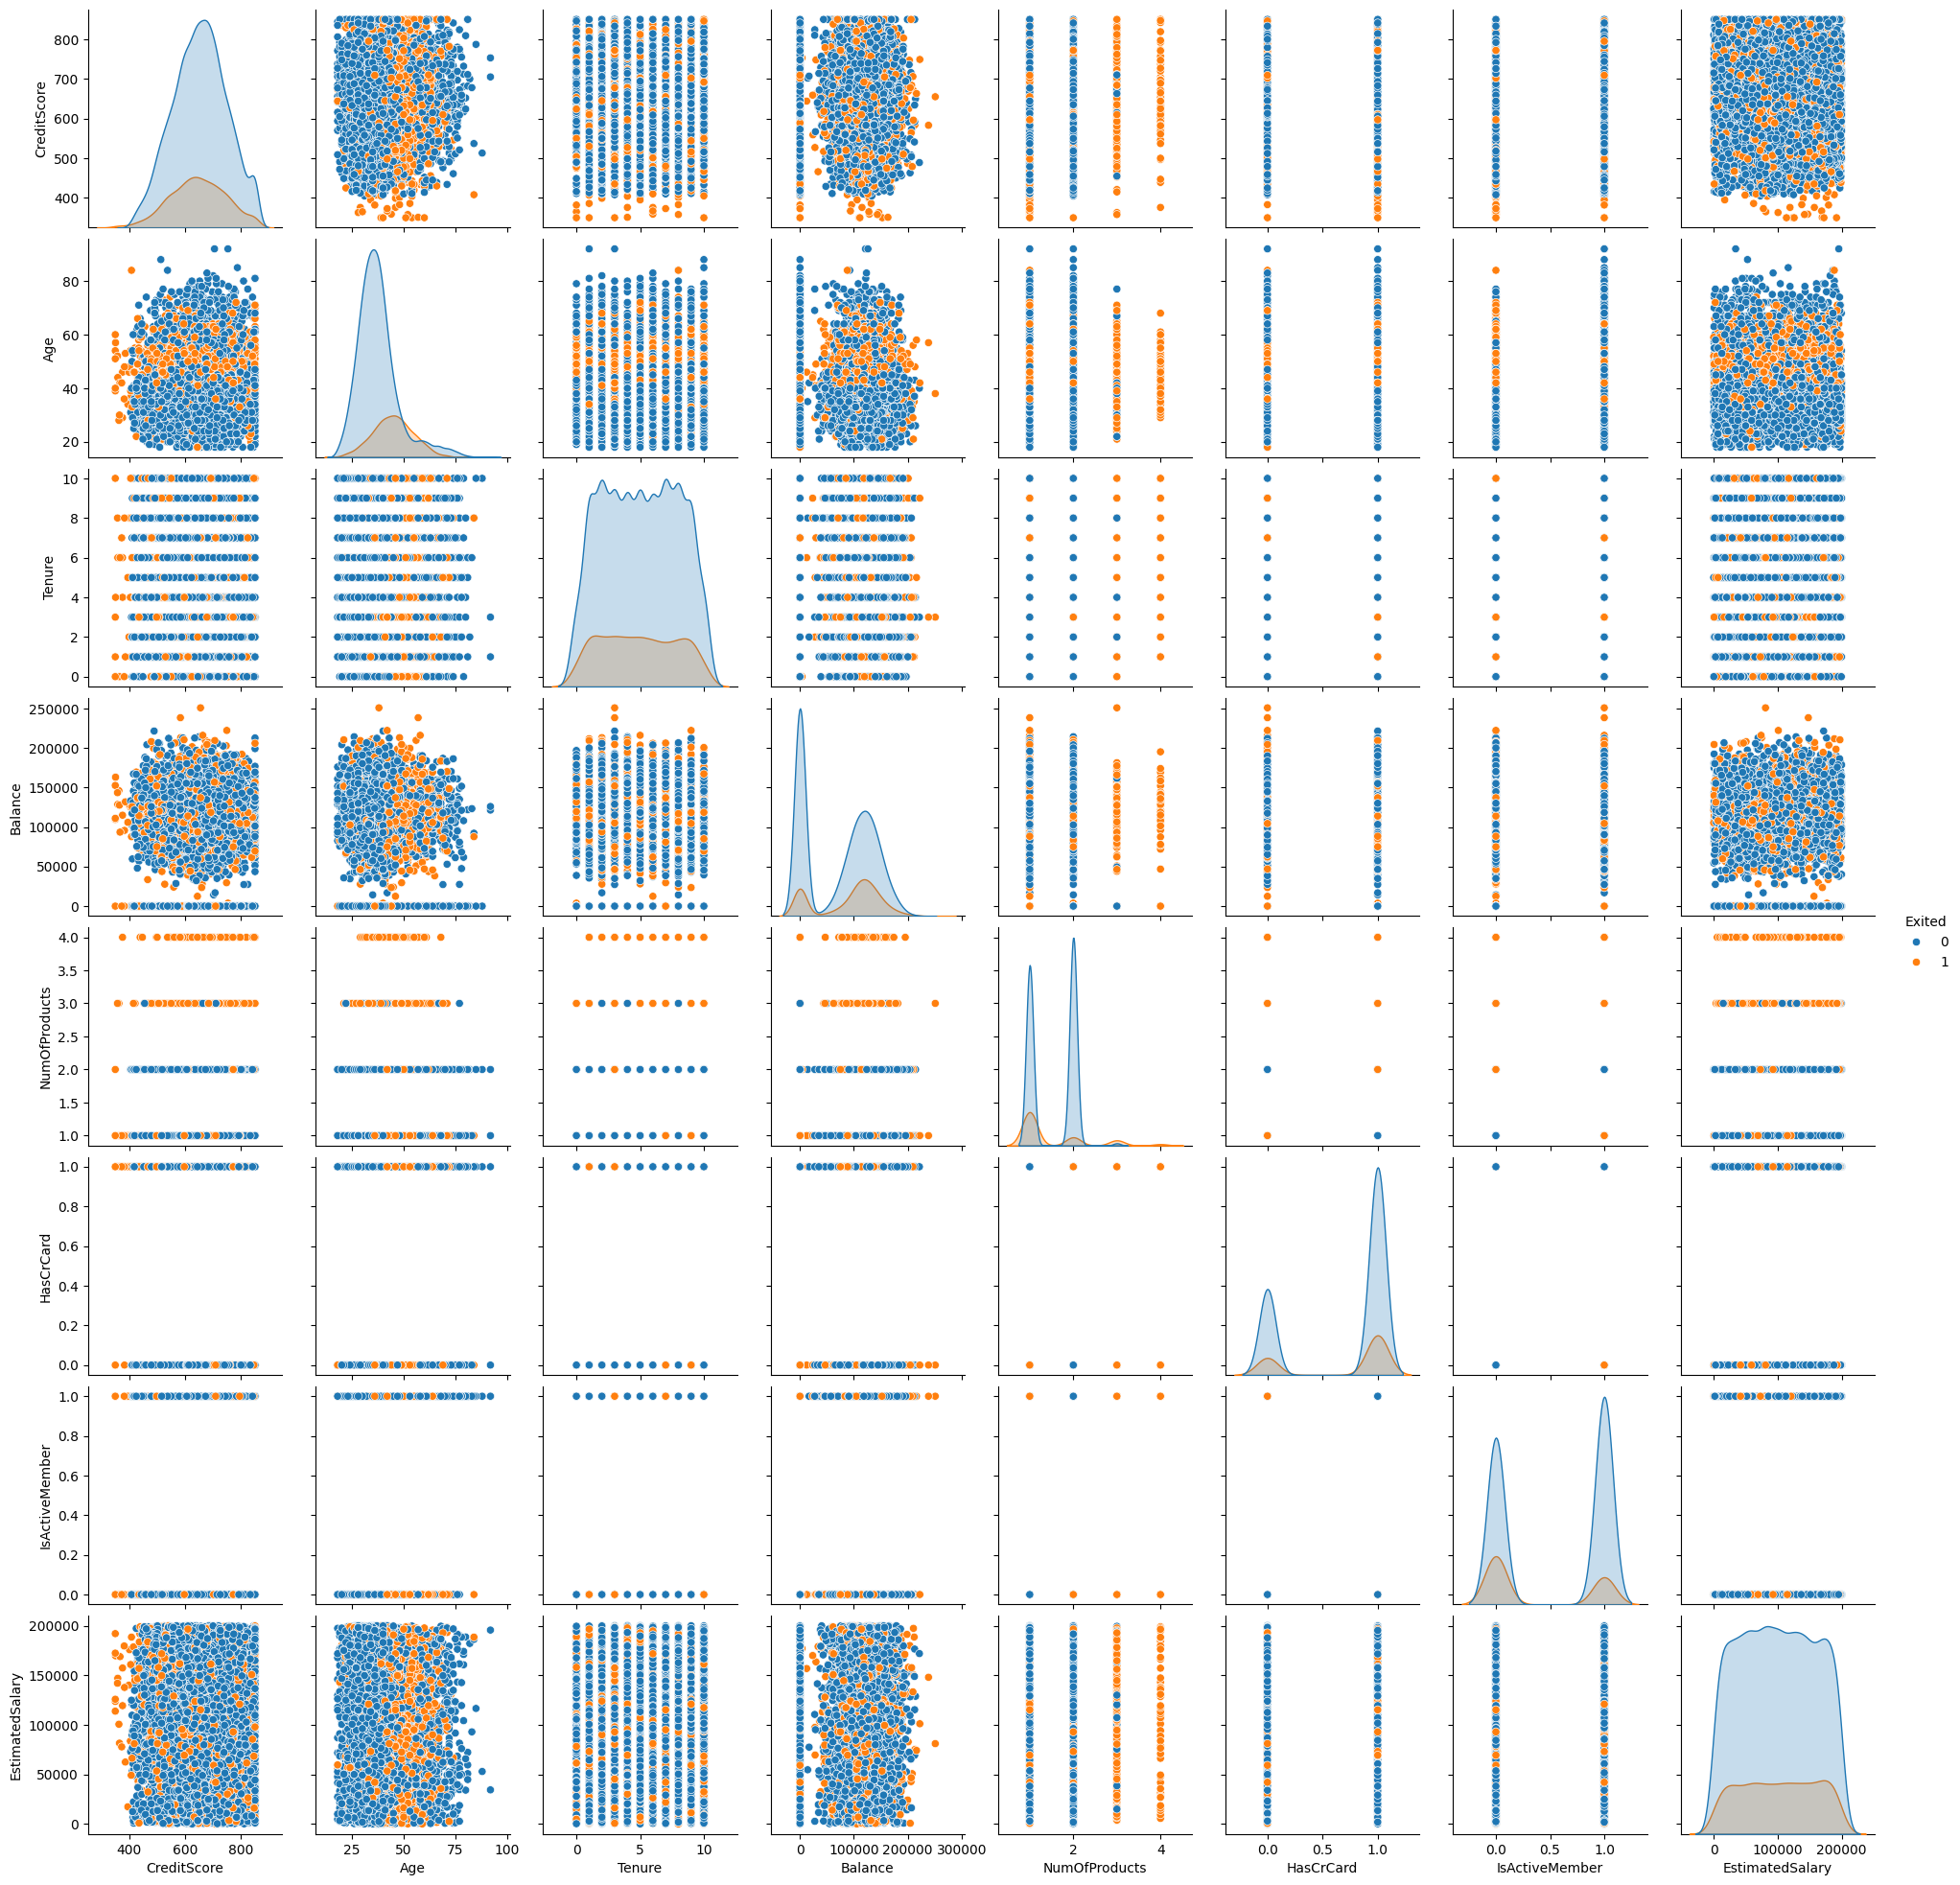

In [25]:
plt.figure(figsize=(15,15))
sns.pairplot(df, hue="Exited",diag_kind='kde')

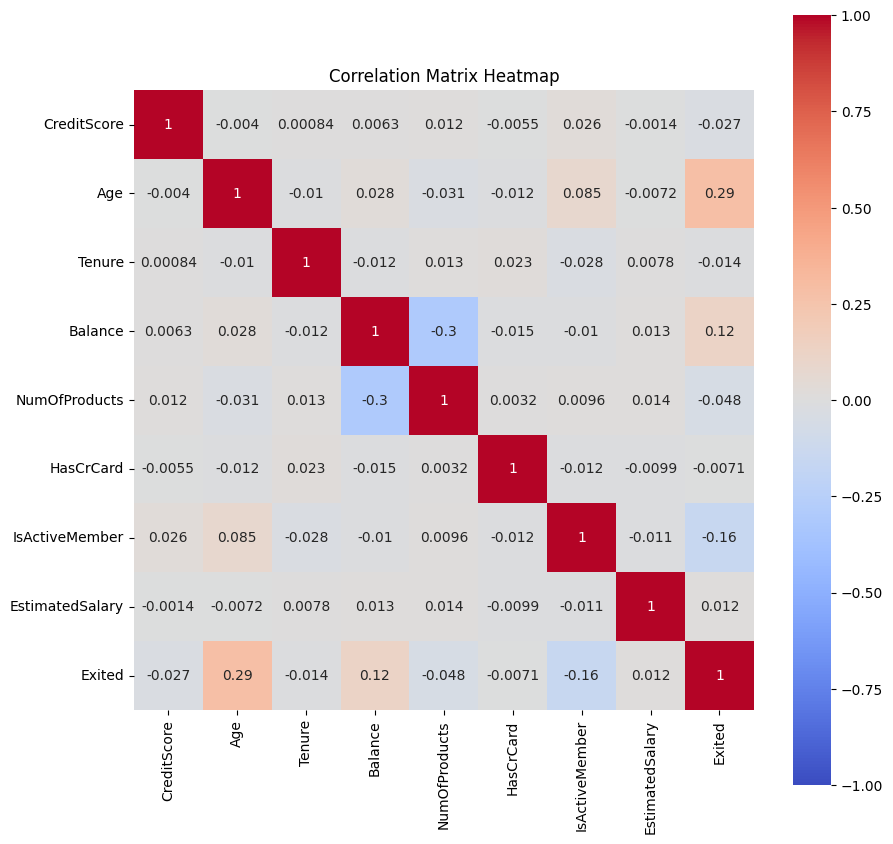

In [26]:
# Select only numeric columns from the DataFrame for the correlation calculation
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 10))  # Set the figure size for better readability
sns.heatmap(numeric_df.corr(), vmax=1, vmin=-1, annot=True, cmap="coolwarm", square=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

<b>Observations:</b><br>
<ul><li>The pair plot and heat map reveal no notable correlations between the variables.</ul></li>
<ul><li>The pair plot indicates distinct clustering patterns in certain variables: Balance (2 clusters), Num of Products (3-4 clusters), HasCrCards (2 clusters), and IsActiveMember (2 clusters).</ul></li>
<ul><li>Both exited and non-exited customers are represented across all clusters. However, due to class imbalance, exited customers are significantly fewer than non-exited customers.</ul></li>

In [27]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=False,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of variable for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=False,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],

        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

<b>Observations:</b><br>
<ul><li>CreditScore: The distribution of this variable is similar across both classes of the target variable, and the presence of outliers does not impact the distribution. Therefore, CreditScore is a poor predictor.</ul></li>
<ul><li>Age: The median age is higher for customers who exited the bank compared to those who stayed, with more outliers among the exited customers. This suggests that customers around the median age of 45 are more likely to leave the bank. Age is thus considered a weak predictor of the target variable.</ul></li>
<ul><li>Balance: There is a high concentration of customers with a balance of zero among those who exited. Additionally, the interquartile range (IQR) for balance is narrower for exited customers compared to those who stayed, and the median balance is slightly higher for those who exited. Consequently, Balance is regarded as a very weak predictor.</ul></li>
<ul><li>EstimatedSalary: This variable has a nearly uniform distribution across both classes, indicating little predictive power.</ul></li>

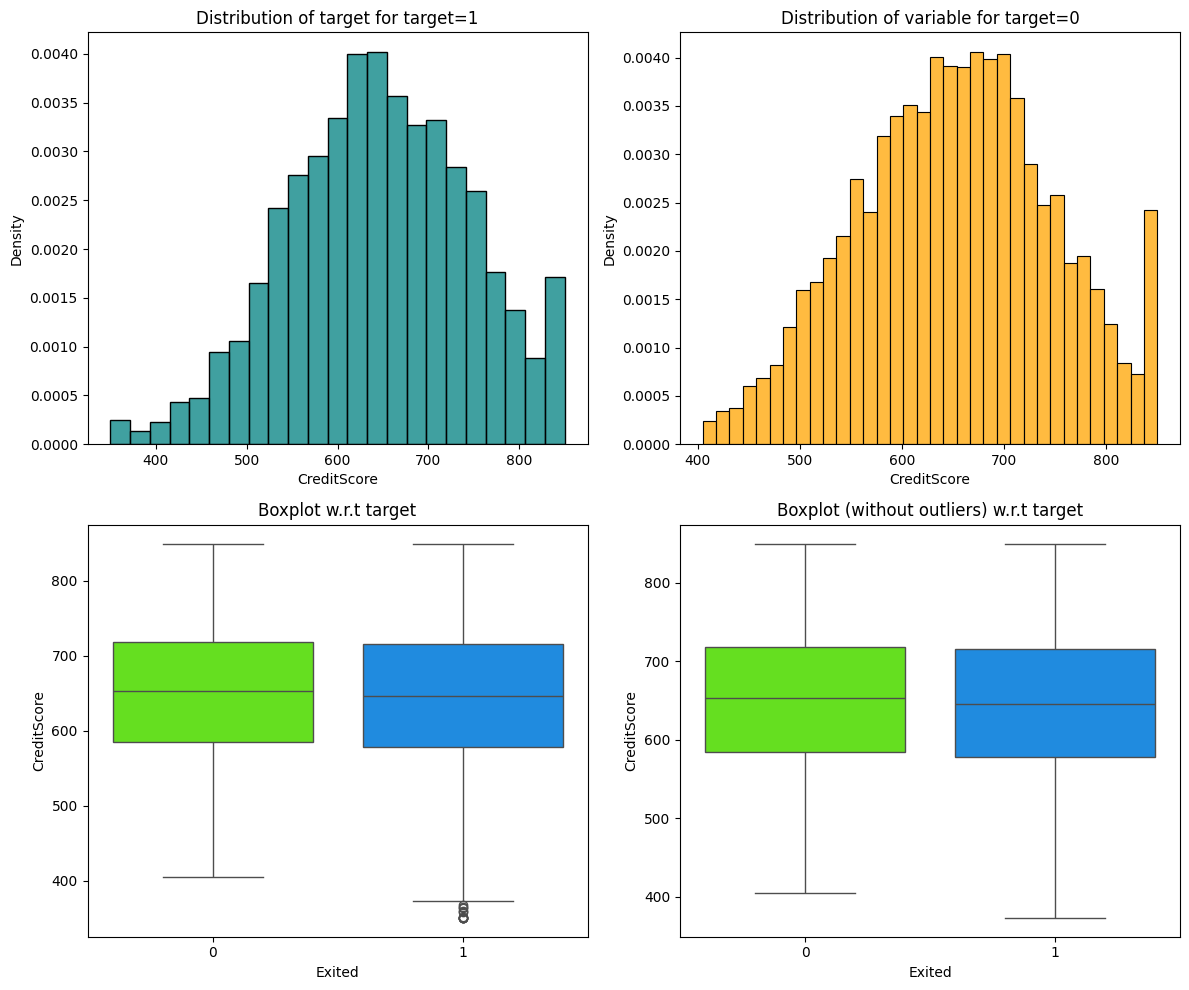

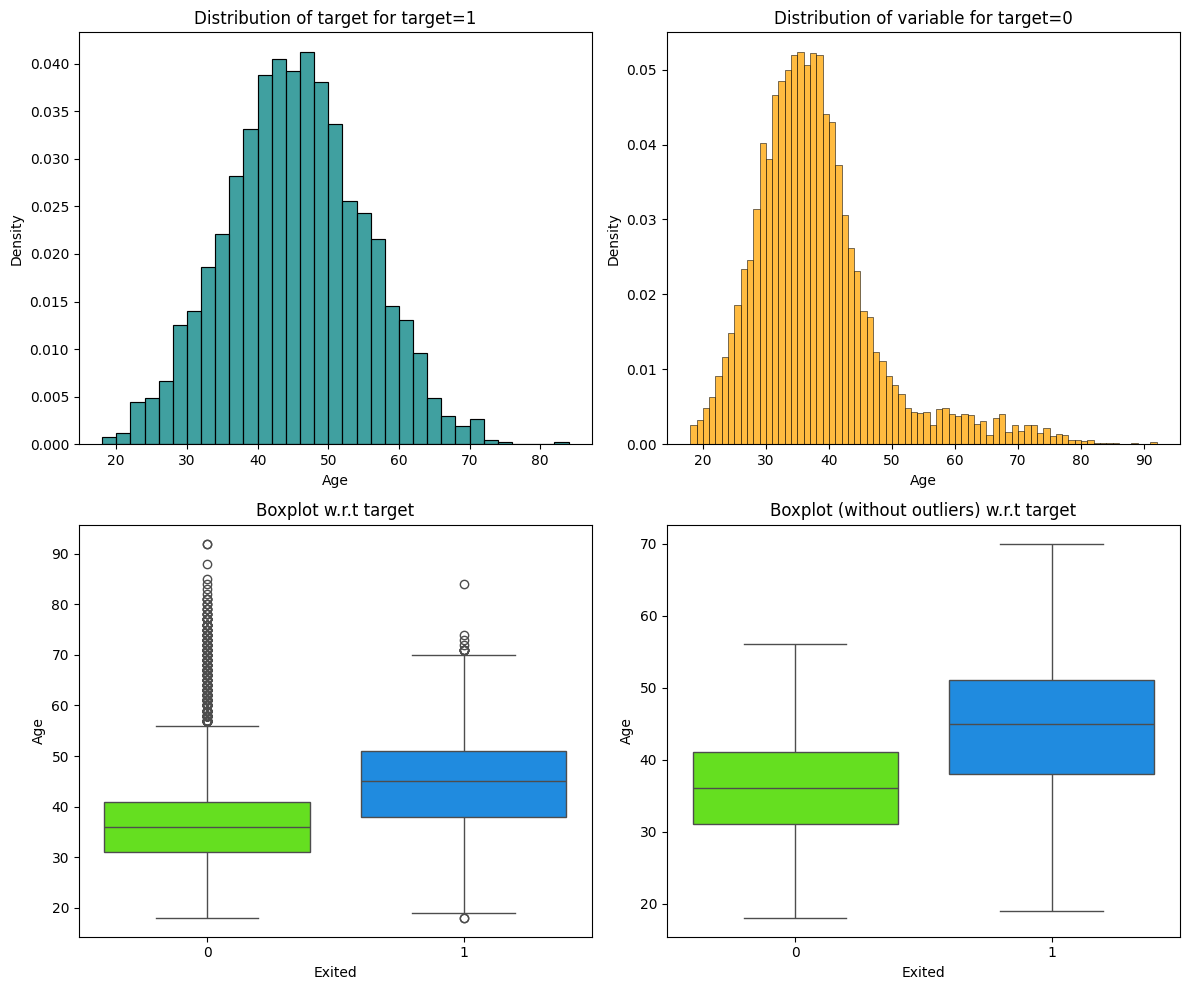

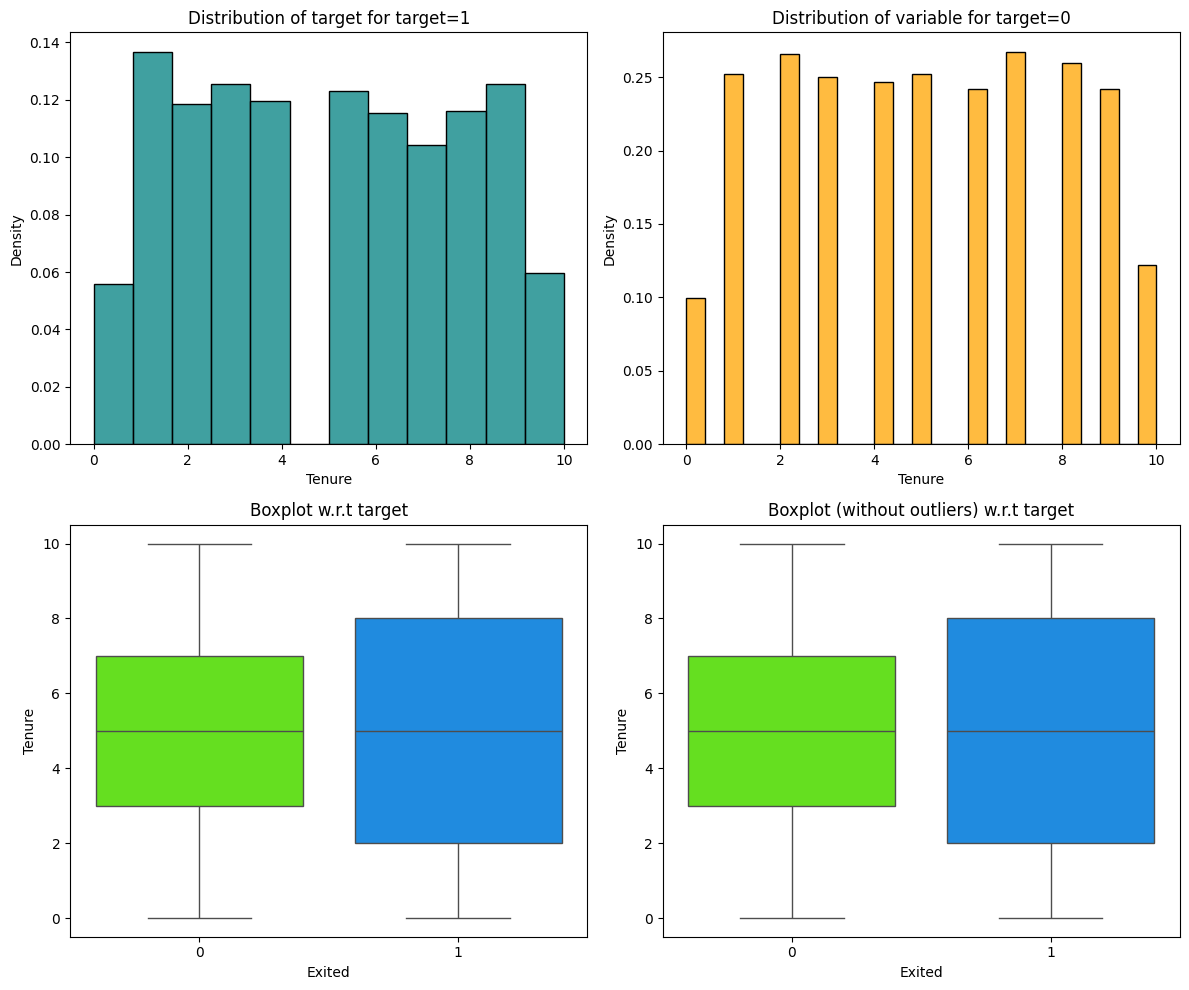

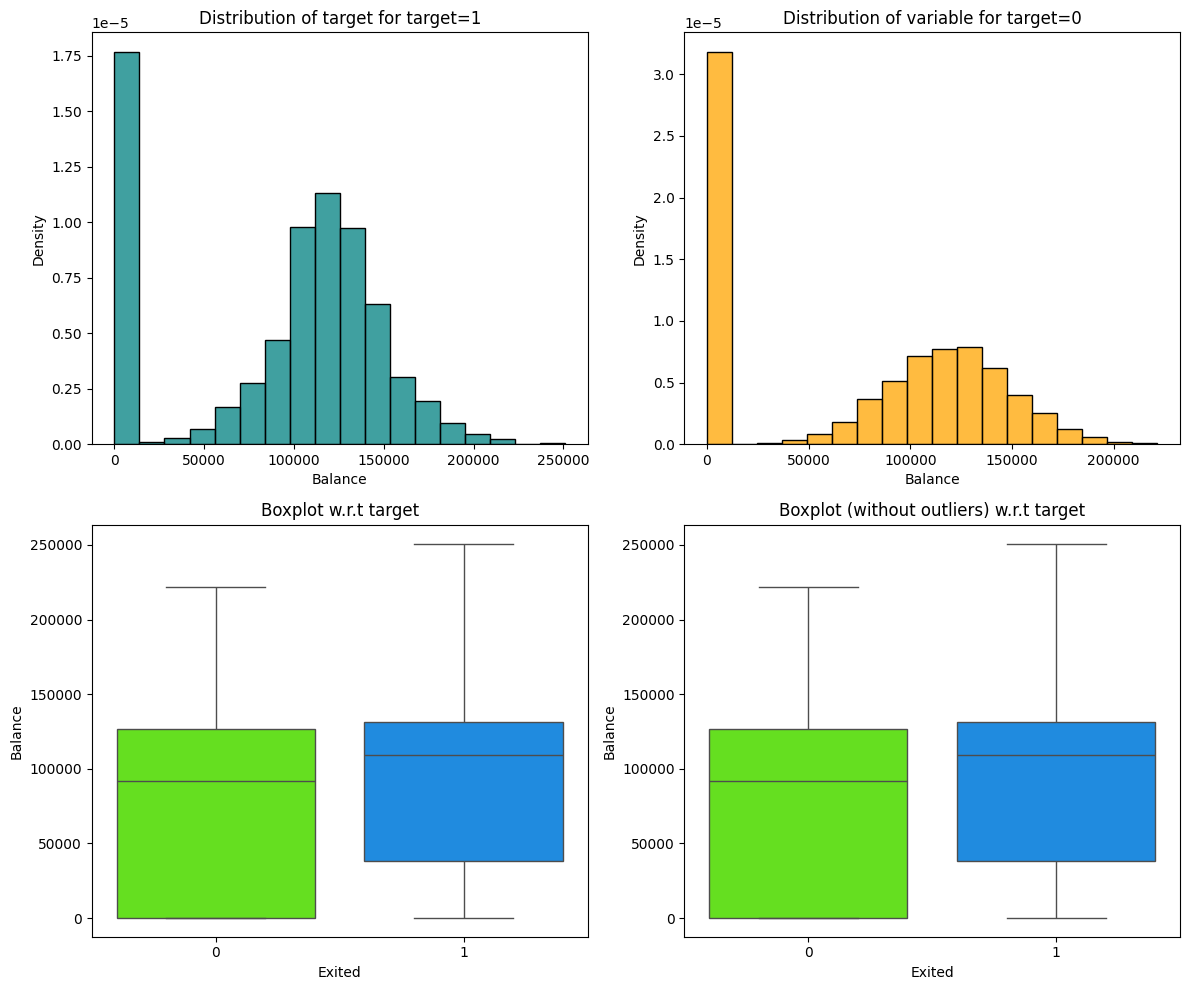

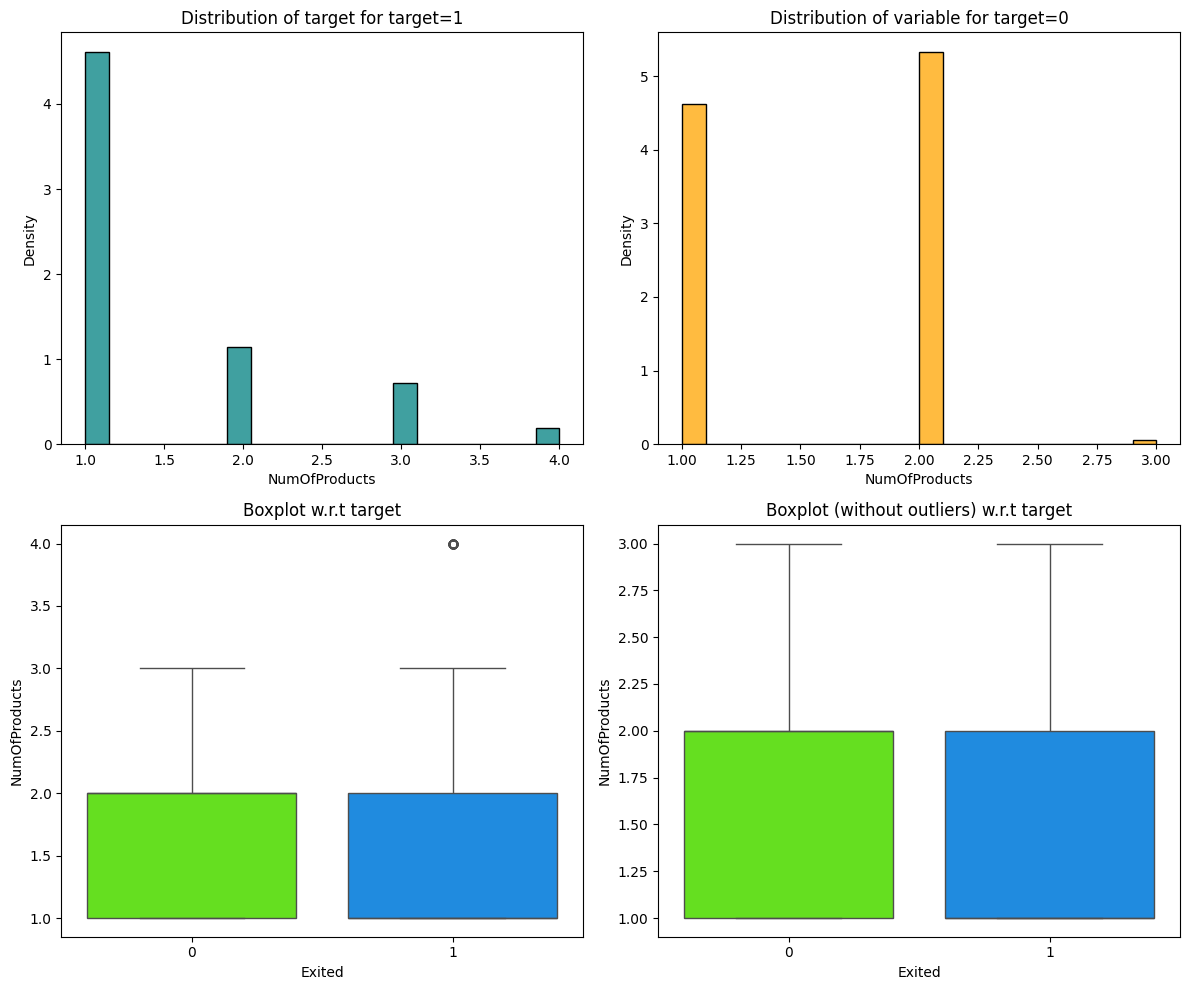

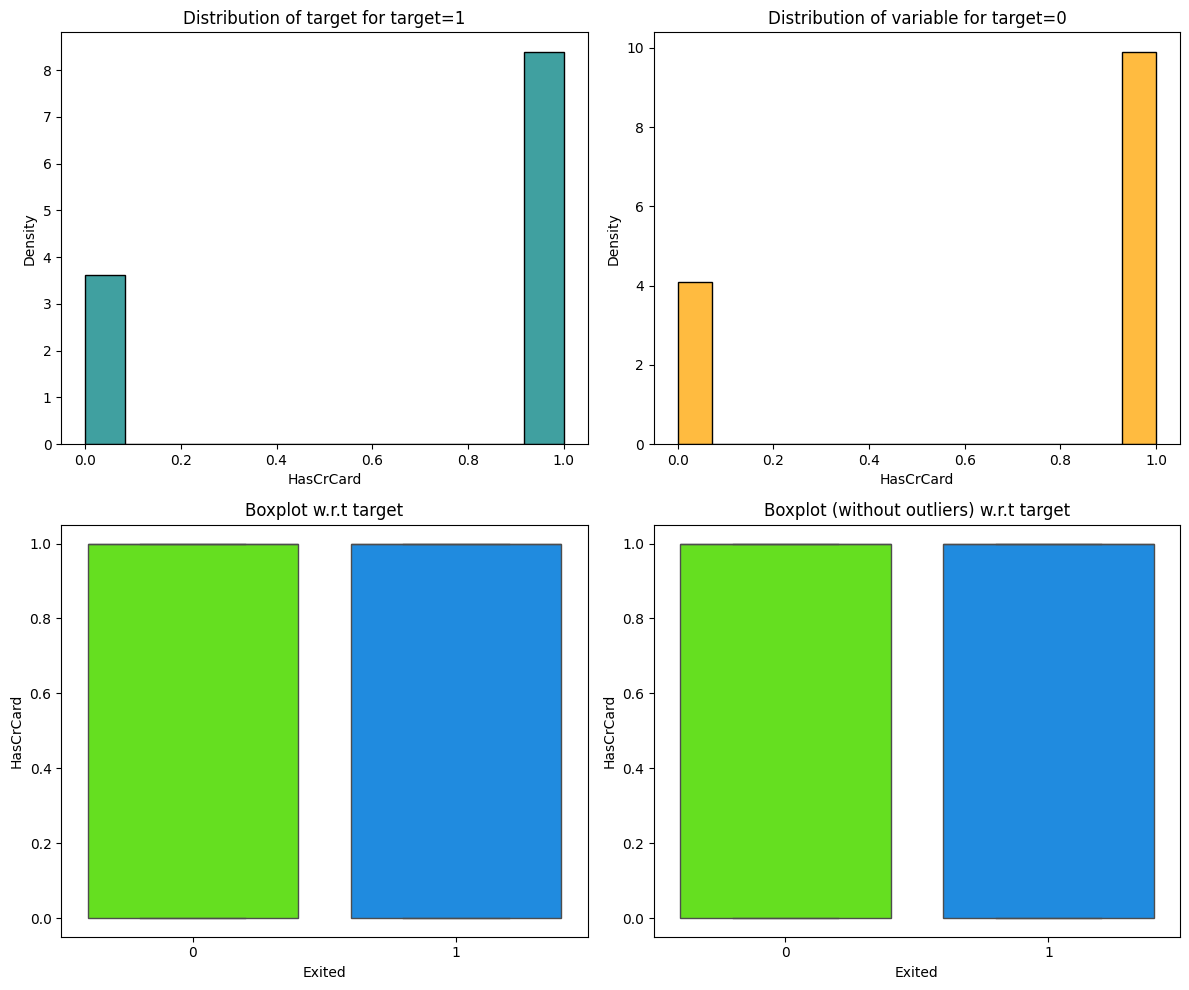

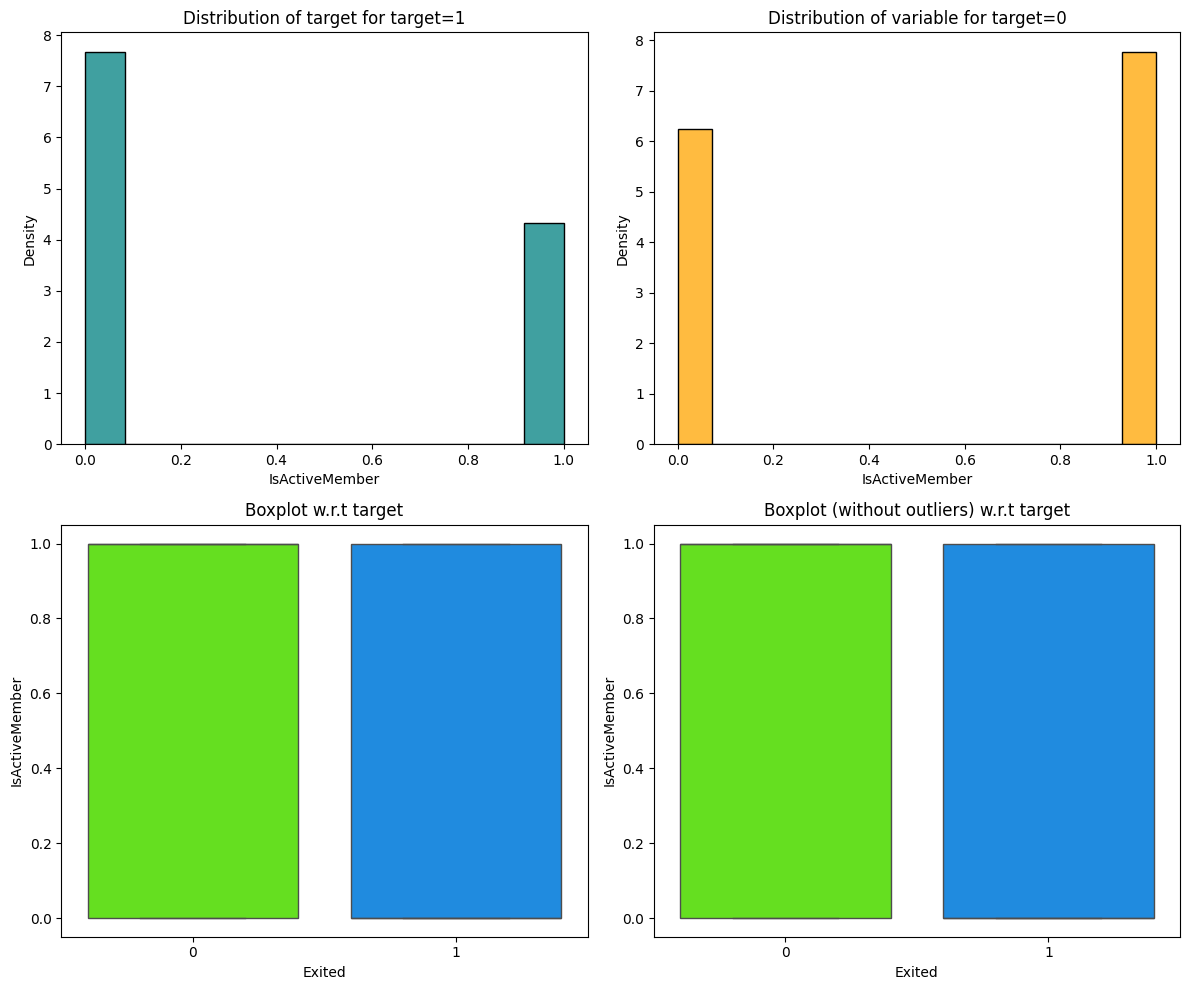

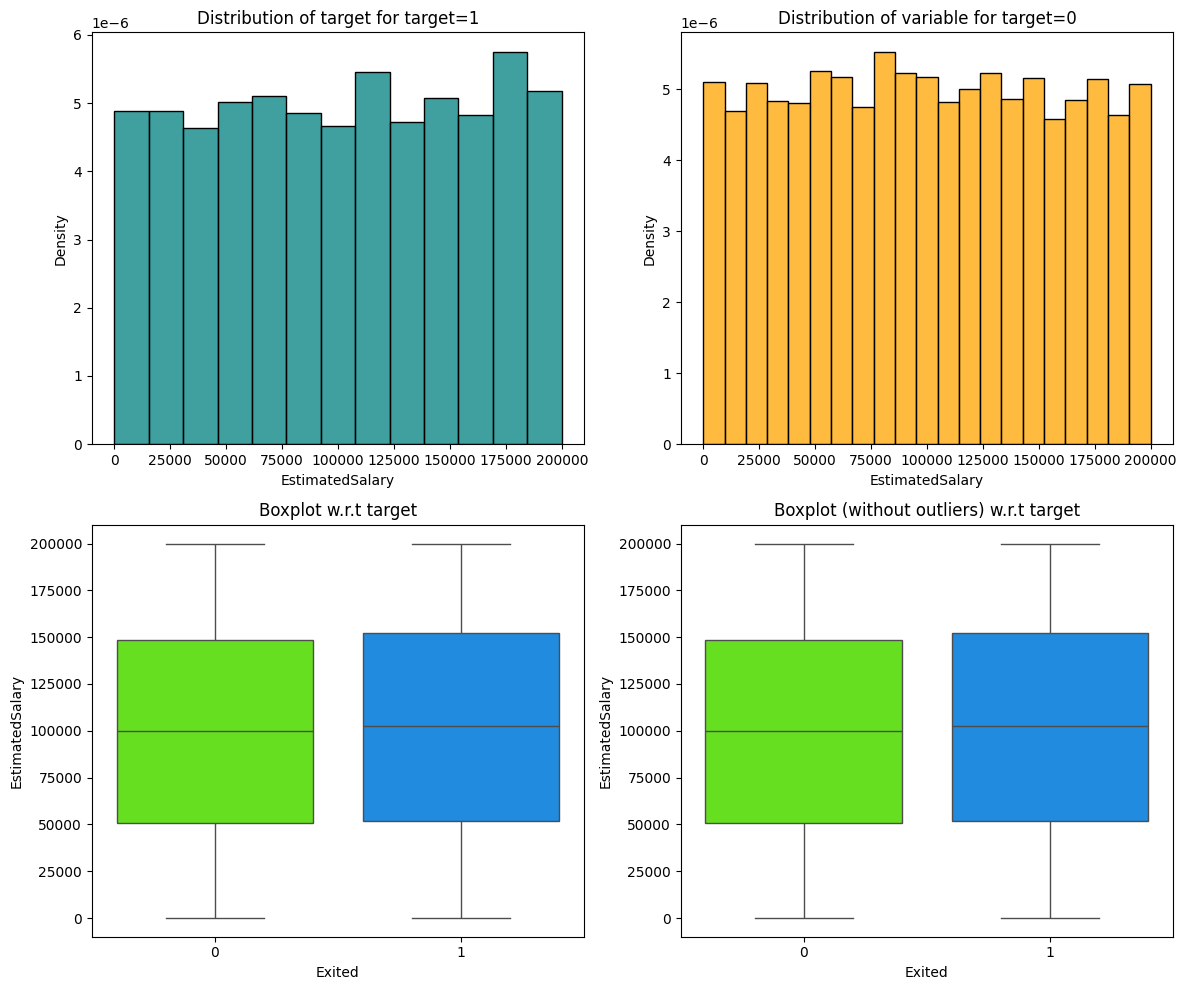

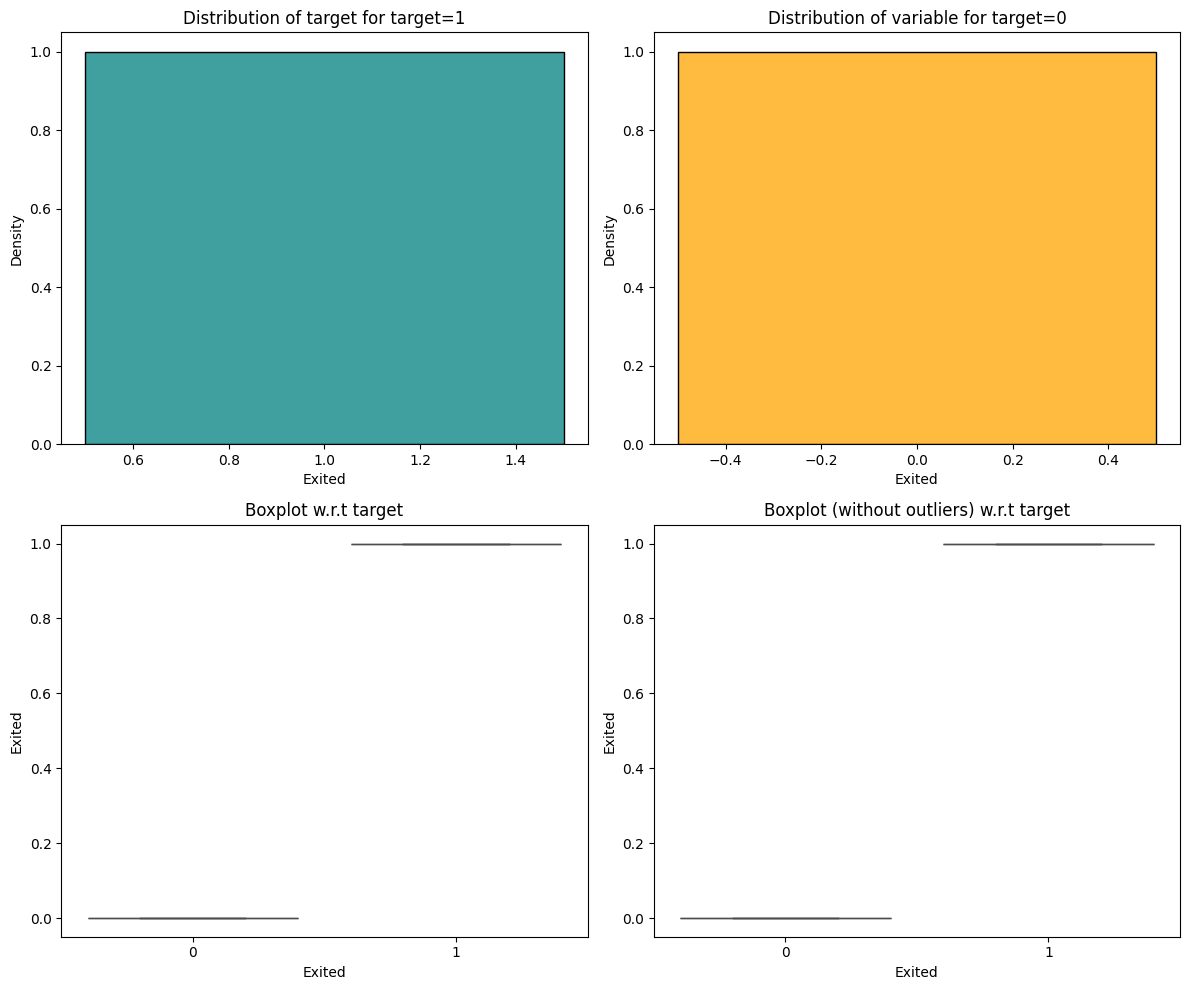

In [28]:
# Define `numerical` as the list of numeric column names in `df`
numerical = df.select_dtypes(include=['number']).columns

# Example loop to call `distribution_plot_wrt_target` for each numeric column
for i in numerical:
    distribution_plot_wrt_target(df, i, 'Exited')

In [29]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

<b>Observations<b><br>
<ul><li>Geography: The highest proportion of exited customers comes from Germany, while Spain and France show almost identical exit ratios. This variable is considered a reasonably good predictor.</ul></li>
<ul><li>Gender: A greater proportion of exited customers are female, making Gender a fairly good predictor.</ul></li>
<ul><li>NumOfProducts: All customers with 4 products, as well as a large proportion of those with 3 products, have exited. The lowest exit ratio is among customers with 2 products, indicating strong predictive power for this variable.</ul></li>
<ul><li>HasCrCard: The exit ratio is nearly the same for customers with and without credit cards, making this a very poor predictor.</ul></li>
<ul><li>IsActiveMember: A higher proportion of non-active customers have exited compared to active ones, making this a fairly good predictor.</ul></li>

Exited        0     1    All
Geography                   
All        7963  2037  10000
Germany    1695   814   2509
France     4204   810   5014
Spain      2064   413   2477
------------------------------------------------------------------------------------------------------------------------


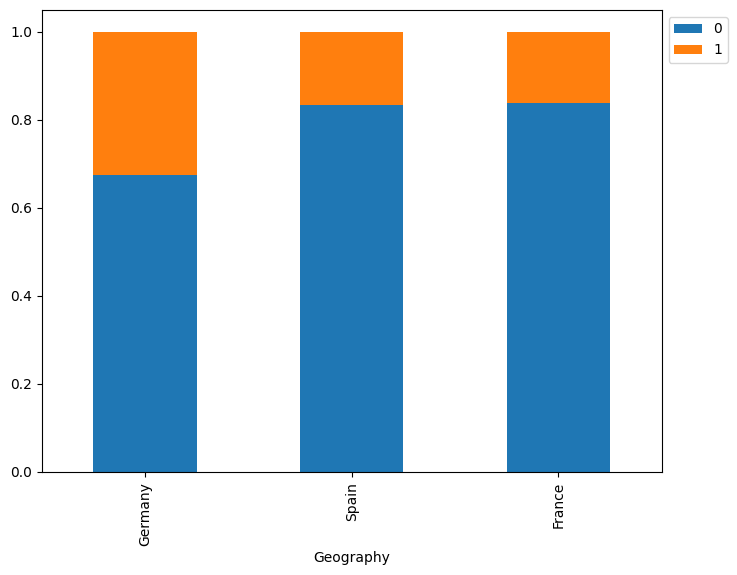

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


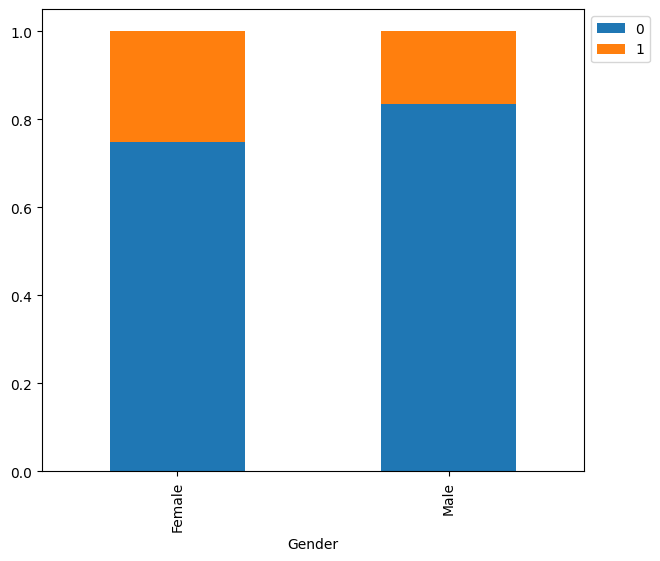

Exited            0     1    All
NumOfProducts                   
All            7963  2037  10000
1              3675  1409   5084
2              4242   348   4590
3                46   220    266
4                 0    60     60
------------------------------------------------------------------------------------------------------------------------


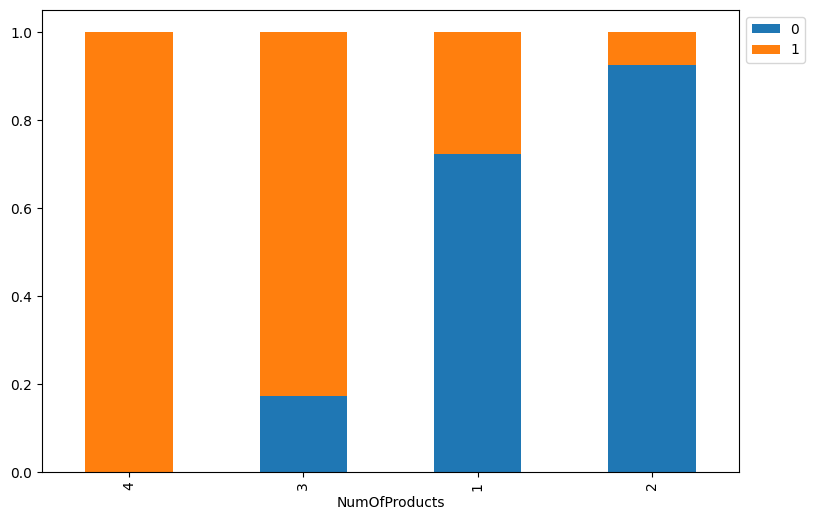

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


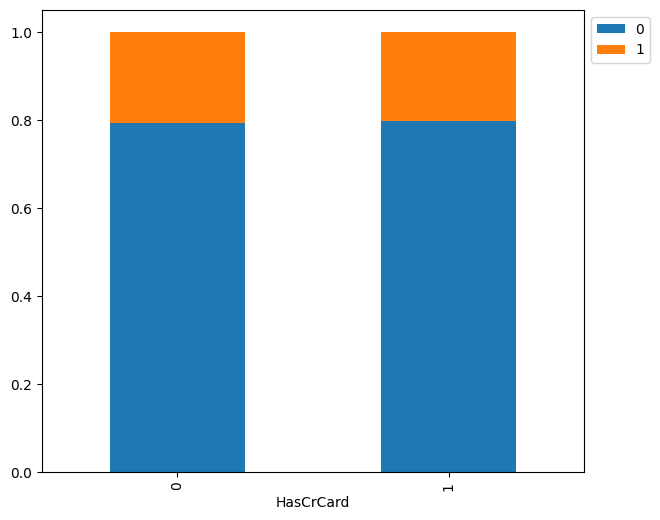

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


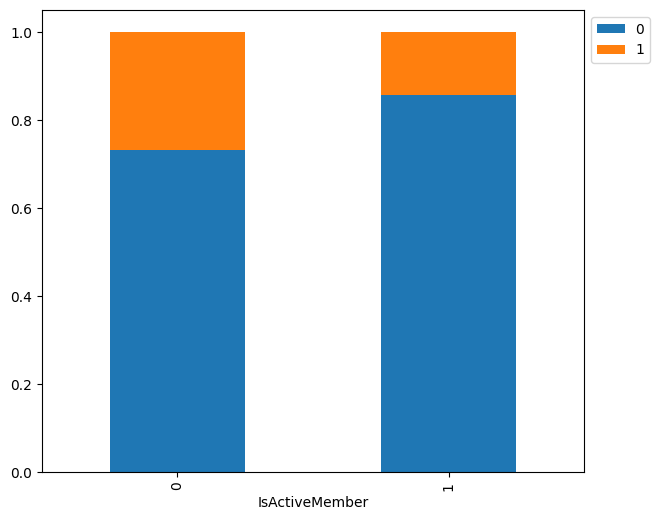

In [30]:
categorical = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

# ploting the categorical variables
for i in categorical:
    stacked_barplot(df, i, 'Exited')

<b>EDA Insights</b><br><br>
From the Univariate Analysis we conclude:

<ul><li>All bank customers come are based in France, Germany or Spain and their Age vary from 18 to 92 years old.</ul></li>
<ul><li>The majority of customers are Males, from France, have credit cards and have not exited the bank</ul></li>
From the Bivariate Anslysis we conclude:

<ul><li>There is no colinearity or correlation observed between features.</ul></li>
<ul><li>The fairly good predictors are: Age, Geography, Gender, Num of products and IsActiveMember</ul></li>
<ul><li>Feature of customers who are most likely to exit the bank are :<br><br>
<ul><li>Age: Ranges from 28 to 52, with a median of 45</ul></li>
<ul><li>Location: Germany</ul></li>
<ul><li>Gender: Female</ul></li>
<ul><li>Number of Products: 3 to 4</ul></li>
<ul><li>Active Member: No</ul></li>

##Data Pre-Processing

<b>Data Pre-processing</b><br><br>
Splitting the target variable and predictors

In [31]:
X = df.drop('Exited',axis=1)
y = df['Exited']

Applying one-hot-encoding for the categorical features

In [32]:
dummy_cat = ['Geography','Gender']
X = pd.get_dummies(X,columns=dummy_cat,drop_first= True)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


3.Scaling the numerical data using zscore to unite the distribution of all variables to a mean of 0 and a std of 1.


In [33]:
# to scale the data
from scipy.stats import zscore
X_Scaled = X.apply(zscore)
X_Scaled.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.578736,-0.573809,-1.095988
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.578736,1.742740,-1.095988
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.578736,-0.573809,-1.095988
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,-0.578736,-0.573809,-1.095988
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.578736,1.742740,-1.095988


Split the data to test and train

In [34]:
# Split the non-scaled data into train and test
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [35]:
# Split the scaled data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_Scaled, y, test_size=0.2, random_state=1, stratify=y)

In [36]:
# Splitting the Train dataset into the Training and Validation set.
X_train, X_valid, y_train, y_valid = train_test_split(X_train,y_train, test_size = 0.2, random_state = 42,stratify = y_train)

In [37]:
#displaying the shape of train and test data sets to confirm the split was successful
print(f''' X_train shape: {X_train.shape}
 X_test shape: {X_test.shape}
 X_valid shape: {X_valid.shape}
 y_valid shape: {y_valid.shape}
 y_train shape: {y_train.shape}
 y_test shape: {y_test.shape}''')

 X_train shape: (6400, 11)
 X_test shape: (2000, 11)
 X_valid shape: (1600, 11)
 y_valid shape: (1600,)
 y_train shape: (6400,)
 y_test shape: (2000,)


4.Data Oversampling: To balance the target variable class ration we will prepare an oversampled train and test datasets using the SMOTE algorithm train data is zscore scaled

In [38]:
print("Before UpSampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before UpSampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)

X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After UpSampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After UpSampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After UpSampling, the shape of X_train: {}".format(X_train_over.shape))
print("After UpSampling, the shape of y-train: {} \n".format(y_train_over.shape))

Before UpSampling, counts of label 'Yes': 1304
Before UpSampling, counts of label 'No': 5096 

After UpSampling, counts of label 'Yes': 5096
After UpSampling, counts of label 'No': 5096 

After UpSampling, the shape of X_train: (10192, 11)
After UpSampling, the shape of y-train: (10192,) 



In [39]:
y_train = y_train.to_numpy()
y_valid = y_valid.to_numpy()
y_test = y_test.to_numpy()

In [40]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

5.Data Undersampling: To balance the target variable class ration we will prepare an undersampled train and test datasets using the Random Under Sampler noting that the train data is zscore scaled

In [41]:
#applting the random under sampler using sampling strategy 0.5
random_us = RandomUnderSampler(random_state=1, sampling_strategy = 0.5)
X_train_un, y_train_un = random_us.fit_resample(X_train, y_train)

print("After UpSampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After UpSampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))


print("After UpSampling, the shape of X_train: {}".format(X_train_un.shape))
print("After UpSampling, the shape of y-train: {} \n".format(y_train_un.shape))

After UpSampling, counts of label 'Yes': 1304
After UpSampling, counts of label 'No': 2608 

After UpSampling, the shape of X_train: (3912, 11)
After UpSampling, the shape of y-train: (3912,) 



In [42]:
#defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

The dataset now is ready for modeling noting that the over sampled and under sampled data will be utilized only if required to enhance the model performance.

##Model Building##

<b>Model building</b><br><br>
Our key performance metric is the Recall as we are aiming to reduce the False Negatives and hence, predict correctly the customers that are most likely to exit the bank and take early actions to avoid this from occuring. We will start by a very simple model using the rule of thumb parameters as initial parameters, observe the performance and start enhancing it.

In [43]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train)

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: 1.2558869701726845, 1: 4.9079754601226995}

In [44]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(1)
import random
random.seed(1)
tf.random.set_seed(1)

In [45]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 25
batch_size = 64

###Neural Network with SGD Optimizer###

<B>Choose the metric of choice with proper rationale - Train a Neural Network model with SGD as an optimizer:</b><br><br>
<ul><li>Hidden layers = 2</ul></li>
<ul><li>Activation function for hidden layers = Relu</ul></li>
<ul><li>Output layer with 1 nodes</ul></li>
<ul><li>Output Activation function = Sigmoid</ul></li>
<ul><li>Output loss function = Cross Entropy (since this is a classification problem)</ul></li>
<ul><li>Optimizer = SGD</ul></li>
<ul><li>epochs = 20</ul></li>
<ul><li>Data is scaled using zscore</ul></li>

In [46]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [ ]:
# Initializing the model
model_01 = Sequential()

# Adding the first layer with 64 neurons, ReLU as the activation function
model_01.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Adding the second hidden layer with 32 neurons, ReLU as the activation function
model_01.add(Dense(32, activation='relu'))

# Adding the output layer with one neuron and Sigmoid as the activation function
model_01.add(Dense(1, activation='sigmoid'))

# Compiling the model with SGD optimizer
model_01.compile(optimizer=SGD(learning_rate=0.01),  # Specify learning rate if needed
                 loss='binary_crossentropy',  # Use binary cross-entropy for binary classification
                 metrics=['accuracy'])

In [ ]:
# Model summary
model_01.summary()


Following is the  breakdown of each layer in the model summary and an explanation of the parameter counts:

<b>Model Summary Analysis</b><br><br>
<b>First Layer (Dense, 64 Neurons):></b><br><br>

<ul><li>Output Shape: <br>(None, 64) indicates that each input sample will produce an output vector of size 64.<br><br>
Parameters (Param #): 768<br><br>
<ul><li>This is calculated as input_dim * units + units or 11 * 64 + 64 = 768.<br></ul></li>
<ul><li>The additional 64 parameters come from the bias term for each of the 64 neurons.</ul></li><br><br>
<b>Second Layer (Dense, 32 Neurons):</b><br>

<ul><li>Output Shape: (None, 32) shows that each sample will produce an output vector of size 32.</ul></li><br>
<ul><li>Parameters (Param #): 2,080
<ul><li>Calculated as previous layer units * current layer units + current layer units or 64 * 32 + 32 = 2,080.<br><br>
<ul><li>This includes 32 biases, one for each neuron in this layer.</ul></li><br><br>
<b>Output Layer (Dense, 1 Neuron):</b><br>

<ul><li>Output Shape: (None, 1) indicates that each input sample will produce a single output value.</ul></li><br>
<ul><li>Parameters (Param #): 33<br><br>
<ul><li>Calculated as 32 * 1 + 1 = 33, where 32 parameters come from the connections to the previous layer, and 1 parameter is the bias.<br><br>
<b>Total Parameters</b><br><br>
<ul><li>Total Params: 2,881 parameters in the model.<br>
<ul><li>These parameters are trainable, meaning they will be adjusted during training to optimize the model.</ul></li>
<ul><li>Non-Trainable Params: 0 because all layers are fully connected and do not include fixed parameters.</ul></li><br><br>
<b>Summary Remarks</b><br><br>
<ul><li>This model is relatively small (2,881 parameters, 11.25 KB in size), which is efficient for quick training and suited for relatively simple classification tasks, especially if the data has fewer features and is not overly complex.</ul><li>
<ul><li>Each layer progressively reduces the number of neurons, which helps the model learn complex patterns while reducing computational cost as it moves closer to the output.</ul></li>
<ul><li>This configuration is a good starting point for binary classification. You might consider adjusting the architecture if you notice underfitting or overfitting, depending on the complexity of your data.</ul></li>

In [ ]:
# Compiling the model with 'cross entropy' as loss function, 'SGD' Optimizer and 'accuracy' metrics
import time
start = time.time()
model_01.compile(loss='binary_crossentropy',
              optimizer='SGD',
              metrics=['accuracy'])

# Fitting the model on train and validation with 20 epochs
fitted_model_01 = model_01.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(fitted_model_01.history['loss'])
plt.plot(fitted_model_01.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

<b>Model Loss Observations</b><br><br>
    <b>Observations from the Provided Loss Curve</b><br><br>       <b>Convergence Trend</b><br><br>
        <ul><li>Both the training and validation losses are steadily decreasing, which suggests that the model is learning effectively without signs of major overfitting.</ul></li>
        <ul><li>The trend shows a smooth decrease in loss over the epochs, indicating that the model is optimizing well.</ul></li><br><br>
        No Overfitting:

<ul><li>The training and validation losses are closely aligned throughout the training process. This suggests that the model generalizes well to unseen data (validation set) and is not overfitting.</ul></li>
<ul><li> Overfitting would typically show a divergence where the training loss continues to decrease, but the validation loss starts to increase.
        This is not evident in the current plot.</ul></li><br><br>    <b>Saturation Point</b><br><br>
        <ul><li>While the losses are still decreasing, the rate of decrease is slowing down as training progresses. This could indicate that the model is nearing a point of diminishing returns in terms of further loss reduction.</ul></li><br><br>
        <b>Possible Further Training</B><br><br>
        <ul><li>Since there is no significant gap between the training and validation losses and both are still decreasing,
        it might be beneficial to continue training for a few more epochs to see if the loss can be reduced further.
        However, you should monitor for any signs of overfitting.</ul></li>
<b>Learning Rate and Optimization</b><br><br>
        <ul><li>The smooth decrease in loss indicates that the learning rate is likely set appropriately for the optimizer (SGD).
        If the loss had been oscillating or diverging, it might have suggested a need to adjust the learning rate.</ul></li><br>
<b>Recommendations</b><br><br>
<ul><li>Continue Training: Consider training for additional epochs if the trend continues.</ul></li>
        <ul><li>Monitor for Overfitting: Keep an eye on the validation loss in case it starts increasing, which would indicate overfitting.</ul></li>
        <ul><li><strong>Early Stopping: You could also consider adding early stopping to automatically stop training when the validation loss ceases to improve.</ul></li><br><br>
        This loss curve indicates healthy training behavior, and the model appears to be learning effectively while generalizing well to the validation set.
        Let me know if you’d like further suggestions on model tuning!
    

<b>Observation:</b><br> <br>The error difference between the validation and train set is increasing, hence this indicates overfitting which requires handling. We shall observe further the model performance on other metrics in order to decinde on the next step.<br>

Deriving more metrics

In [ ]:
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
model_01_train_perf = model_performance_classification(model_01, X_train, y_train)
model_01_train_perf

In [ ]:
model_01_valid_perf = model_performance_classification(model_01, X_valid, y_valid)
model_01_valid_perf

- Train F1 score of ~0.79 and test F1 score of ~0.80 indicate consistent performance of the model between training and testing datasets.

- Even though it's a good score, the rate of improvement over the epochs is still low.

In [ ]:
model_01_test_perf = model_performance_classification(model_01, X_test, y_test)
model_01_test_perf

In [ ]:
# defining a function to display the confusion matrix
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))



    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)


    if title:
        plt.title(title)

In [ ]:
# Obtain the y_predict from the X_test
y_pred=model_01.predict(X_test)

#set the threshold to 0.5
y_pred = (y_pred > 0.5)

# Display the classification report
from sklearn import metrics
cr=metrics.classification_report(y_test,y_pred)
print(cr)

The Macro Averge of the Recall is considerably low and since this is still our first model, we can sure enhance this performance. Let us observe the confusion matrix.

In [ ]:
#displaying the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exiting','Exiting']
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

<b>Overall Observations</b><br><br>
Accuracy:

The overall accuracy appears reasonable, with a large proportion of predictions being correct (76.60% TP and 8.75% TN).
Sensitivity (Recall for "Exiting"):

Sensitivity or recall for the "Exiting" class can be calculated as
Recall
=
TN
TN + FN
Recall=
TN + FN
TN
​
 , giving an indication of how well the model identifies true "Exiting" cases.
In this case, the model has relatively low recall for the "Exiting" class, as evidenced by the higher number of False Positives compared to True Negatives.
Specificity (Recall for "Not Exiting"):

The model’s ability to correctly identify "Not Exiting" cases (specificity) is relatively high, as indicated by the large number of True Positives and low False Negatives.<br><br>
<b>Recommendations</b><br><br>
Balance Precision and Recall for "Exiting":

The model could benefit from adjustments to improve its precision for the "Exiting" class (reducing False Positives) or recall for this class (increasing True Negatives).
Techniques such as adjusting the classification threshold or applying class weights can help if "Exiting" cases are more critical to identify accurately.
Consider Adjusting the Threshold:

If correctly identifying "Exiting" customers is crucial, consider lowering the classification threshold for this class to reduce False Negatives, though this may increase False Positives.
Evaluate Precision-Recall Trade-Off:

If the "Exiting" class is the primary focus, you may want to look at precision-recall metrics or F1 Score specifically for this class to get a better sense of the trade-off between identifying true "Exiting" cases and avoiding false alarms.
Conclusion
The confusion matrix shows that the model is performing well overall, especially in identifying "Not Exiting" cases accurately. However, there is room for improvement in identifying true "Exiting" cases. Adjusting the model or threshold could enhance performance depending on the specific goals and priorities of the application.

<b>Model Performance Improvement</b><br><br>
Moving on forward, a multiple models will be created using different combinations of hyperparameters including:

<ul><li>Type of Optimizer</ul></li>
<ul><li>Number of Layers</ul></li>
<ul><li>Number of Neurons in a layer</ul></li>
<ul><li>Weight initialization</ul></li>
<ul><li>Regularization techniques (Dropout and Batch Normalization)</ul></li>
<ul><li>Learning Rate</ul></li>
<ul><li>Batch Size</ul></li><br>
Also, we will utilize the GridSeachCV and Keras Tuner to tune some of the above hyperparameters.<br>

Finally, we will keep in mind that the data target classes are imbalanced, hence we will utilize the over_sampled and under_sampled data prepared in the data pre-processing step whenever required.<br>

In each new model, the hyperparameter will be stated, the model performance will be evaluated on several metrics including the our most important metric which is the Recall.


Following is the  breakdown of each layer in the model summary and an explanation of the parameter counts:

<b>Model Summary Analysis</b><br><br>
<b>First Layer (Dense, 64 Neurons):></b><br><br>

<ul><li>Output Shape: <br>(None, 64) indicates that each input sample will produce an output vector of size 64.<br><br>
Parameters (Param #): 768<br><br>
<ul><li>This is calculated as input_dim * units + units or 11 * 64 + 64 = 768.<br></ul></li>
<ul><li>The additional 64 parameters come from the bias term for each of the 64 neurons.</ul></li><br><br>
<b>Second Layer (Dense, 32 Neurons):</b><br>

<ul><li>Output Shape: (None, 32) shows that each sample will produce an output vector of size 32.</ul></li><br>
<ul><li>Parameters (Param #): 2,080
<ul><li>Calculated as previous layer units * current layer units + current layer units or 64 * 32 + 32 = 2,080.<br><br>
<ul><li>This includes 32 biases, one for each neuron in this layer.</ul></li><br><br>
<b>Output Layer (Dense, 1 Neuron):</b><br>

<ul><li>Output Shape: (None, 1) indicates that each input sample will produce a single output value.</ul></li><br>
<ul><li>Parameters (Param #): 33<br><br>
<ul><li>Calculated as 32 * 1 + 1 = 33, where 32 parameters come from the connections to the previous layer, and 1 parameter is the bias.<br><br>
<b>Total Parameters</b><br><br>
<ul><li>Total Params: 2,881 parameters in the model.<br>
<ul><li>These parameters are trainable, meaning they will be adjusted during training to optimize the model.</ul></li>
<ul><li>Non-Trainable Params: 0 because all layers are fully connected and do not include fixed parameters.</ul></li><br><br>
<b>Summary Remarks</b><br><br>
<ul><li>This model is relatively small (2,881 parameters, 11.25 KB in size), which is efficient for quick training and suited for relatively simple classification tasks, especially if the data has fewer features and is not overly complex.</ul><li>
<ul><li>Each layer progressively reduces the number of neurons, which helps the model learn complex patterns while reducing computational cost as it moves closer to the output.</ul></li>
<ul><li>This configuration is a good starting point for binary classification. You might consider adjusting the architecture if you notice underfitting or overfitting, depending on the complexity of your data.</ul></li>

The Macro Averge of the Recall is considerably low and since this is still our first model, we can sure enhance this performance. Let us observe the confusion matrix.

<b>Model Performance Improvement</b><br><br>
Moving on forward, a multiple models will be created using different combinations of hyperparameters including:

<ul><li>Type of Optimizer</ul></li>
<ul><li>Number of Layers</ul></li>
<ul><li>Number of Neurons in a layer</ul></li>
<ul><li>Weight initialization</ul></li>
<ul><li>Regularization techniques (Dropout and Batch Normalization)</ul></li>
<ul><li>Learning Rate</ul></li>
<ul><li>Batch Size</ul></li><br>
Also, we will utilize the GridSeachCV and Keras Tuner to tune some of the above hyperparameters.<br>

Finally, we will keep in mind that the data target classes are imbalanced, hence we will utilize the over_sampled and under_sampled data prepared in the data pre-processing step whenever required.<br>

In each new model, the hyperparameter will be stated, the model performance will be evaluated on several metrics including the our most important metric which is the Recall.

## Model Performance Improvement

### Neural Network with Adam Optimizer


<B>Choose the metric of choice with proper rationale - Train a Neural Network model with SGD as an optimizer:</b><br><br>
<ul><li>Hidden layers = 2</ul></li>
<ul><li>Activation function for hidden layers = Relu</ul></li>
<ul><li>Output layer with 1 nodes</ul></li>
<ul><li>Output Activation function = Sigmoid</ul></li>
<ul><li>Output loss function = Cross Entropy (since this is a classification problem)</ul></li>
<ul><li>Optimizer = Adam</ul></li>
<ul><li>epochs = 20</ul></li>
<ul><li>Data is scaled using zscore</ul></li>

In [193]:
# Initializing the model
model_02 = Sequential()

# Adding the first layer with 64 neurons, ReLU as the activation function
model_02.add(Dense(64, activation='relu', input_dim=11))

# Adding the second hidden layer with 32 neurons, ReLU as the activation function
model_02.add(Dense(32, activation='relu'))

# Adding the output layer with one neuron and Sigmoid as the activation function
model_02.add(Dense(1, activation='sigmoid'))

# Compiling the model with SGD optimizer
model_02.compile(optimizer=Adam(learning_rate=0.01),  # Specify learning rate if needed
                 loss='binary_crossentropy',  # Use binary cross-entropy for binary classification
                 metrics=['accuracy'])

In [194]:
# Model summary
model_02.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)


Following is the  breakdown of each layer in the model summary and an explanation of the parameter counts:

<b>Model Summary Analysis</b><br><br>
<b>First Layer (Dense, 64 Neurons):></b><br><br>

<ul><li>Output Shape: <br>(None, 64) indicates that each input sample will produce an output vector of size 64.<br><br>
Parameters (Param #): 768<br><br>
<ul><li>This is calculated as input_dim * units + units or 11 * 64 + 64 = 768.<br></ul></li>
<ul><li>The additional 64 parameters come from the bias term for each of the 64 neurons.</ul></li><br><br>
<b>Second Layer (Dense, 32 Neurons):</b><br>

<ul><li>Output Shape: (None, 32) shows that each sample will produce an output vector of size 32.</ul></li><br>
<ul><li>Parameters (Param #): 2,080
<ul><li>Calculated as previous layer units * current layer units + current layer units or 64 * 32 + 32 = 2,080.<br><br>
<ul><li>This includes 32 biases, one for each neuron in this layer.</ul></li><br><br>
<b>Output Layer (Dense, 1 Neuron):</b><br>

<ul><li>Output Shape: (None, 1) indicates that each input sample will produce a single output value.</ul></li><br>
<ul><li>Parameters (Param #): 33<br><br>
<ul><li>Calculated as 32 * 1 + 1 = 33, where 32 parameters come from the connections to the previous layer, and 1 parameter is the bias.<br><br>
<b>Total Parameters</b><br><br>
<ul><li>Total Params: 2,881 parameters in the model.<br>
<ul><li>These parameters are trainable, meaning they will be adjusted during training to optimize the model.</ul></li>
<ul><li>Non-Trainable Params: 0 because all layers are fully connected and do not include fixed parameters.</ul></li><br><br>
<b>Summary Remarks</b><br><br>
<ul><li>This model is relatively small (2,881 parameters, 11.25 KB in size), which is efficient for quick training and suited for relatively simple classification tasks, especially if the data has fewer features and is not overly complex.</ul><li>
<ul><li>Each layer progressively reduces the number of neurons, which helps the model learn complex patterns while reducing computational cost as it moves closer to the output.</ul></li>
<ul><li>This configuration is a good starting point for binary classification. You might consider adjusting the architecture if you notice underfitting or overfitting, depending on the complexity of your data.</ul></li>

In [195]:
# Compiling the model with 'cross entropy' as loss function, 'Adam' Optimizer and 'accuracy' metrics
model_02.compile(loss='binary_crossentropy',
              optimizer='ADAM',
              metrics=['accuracy'])

# Fitting the model on train and validation with 20 epochs
fitted_model_02 = model_02.fit(X_train, y_train, validation_split=0.2,epochs=20)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7844 - loss: 0.5166 - val_accuracy: 0.8164 - val_loss: 0.4266
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8224 - loss: 0.4137 - val_accuracy: 0.8289 - val_loss: 0.3991
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8434 - loss: 0.3787 - val_accuracy: 0.8422 - val_loss: 0.3727
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8608 - loss: 0.3491 - val_accuracy: 0.8383 - val_loss: 0.3619
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8609 - loss: 0.3347 - val_accuracy: 0.8398 - val_loss: 0.3595
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8629 - loss: 0.3280 - val_accuracy: 0.8430 - val_loss: 0.3586
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8649 - loss: 0.3236 - val_accuracy: 0.8469 - val_loss: 0.3580
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8652 - loss: 0.3204 - val_accuracy: 0.

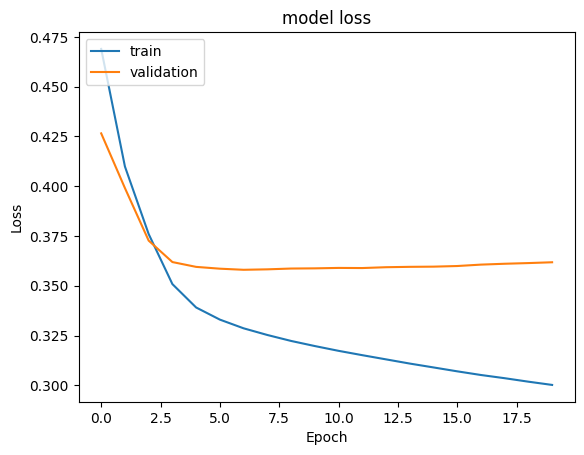

In [264]:
#Plotting Train Loss vs Validation Loss
plt.plot(fitted_model_02.history['loss'])
plt.plot(fitted_model_02.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [237]:
model_02_train_perf = model_performance_classification(model_02, X_train, y_train)
model_02_train_perf

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.46525,0.46525,0.736525,0.503239


In [238]:
model_02_valid_perf = model_performance_classification(model_02, X_valid, y_valid)
model_02_valid_perf

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.858125,0.858125,0.848293,0.849064


In [239]:
model_02_test_perf = model_performance_classification(model_02, X_test, y_test)
model_02_test_perf

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.8635,0.8635,0.864276,0.842912


<b>Model Loss Observations</b><br><br>
    <b>Observations from the Provided Loss Curve</b><br><br>       <b>Convergence Trend</b><br><br>
        <ul><li>Both the training and validation losses are steadily decreasing, which suggests that the model is learning effectively without signs of major overfitting.</ul></li>
        <ul><li>The trend shows a smooth decrease in loss over the epochs, indicating that the model is optimizing well.</ul></li><br><br>
        No Overfitting:

<ul><li>The training and validation losses are closely aligned throughout the training process. This suggests that the model generalizes well to unseen data (validation set) and is not overfitting.</ul></li>
<ul><li> Overfitting would typically show a divergence where the training loss continues to decrease, but the validation loss starts to increase.
        This is not evident in the current plot.</ul></li><br><br>    <b>Saturation Point</b><br><br>
        <ul><li>While the losses are still decreasing, the rate of decrease is slowing down as training progresses. This could indicate that the model is nearing a point of diminishing returns in terms of further loss reduction.</ul></li><br><br>
        <b>Possible Further Training</B><br><br>
        <ul><li>Since there is no significant gap between the training and validation losses and both are still decreasing,
        it might be beneficial to continue training for a few more epochs to see if the loss can be reduced further.
        However, you should monitor for any signs of overfitting.</ul></li>
<b>Learning Rate and Optimization</b><br><br>
        <ul><li>The smooth decrease in loss indicates that the learning rate is likely set appropriately for the optimizer (SGD).
        If the loss had been oscillating or diverging, it might have suggested a need to adjust the learning rate.</ul></li><br>
<b>Recommendations</b><br><br>
<ul><li>Continue Training: Consider training for additional epochs if the trend continues.</ul></li>
        <ul><li>Monitor for Overfitting: Keep an eye on the validation loss in case it starts increasing, which would indicate overfitting.</ul></li>
        <ul><li><strong>Early Stopping: You could also consider adding early stopping to automatically stop training when the validation loss ceases to improve.</ul></li><br><br>
        This loss curve indicates healthy training behavior, and the model appears to be learning effectively while generalizing well to the validation set.
        Let me know if you’d like further suggestions on model tuning!
    

<b>Observation:</b><br> <br>The error difference between the validation and train set is increasing, hence this indicates overfitting which requires handling. We shall observe further the model performance on other metrics in order to decinde on the next step.<br>

Deriving more metrics

In [197]:
# defining a function to display the confusion matrix
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))



    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)


    if title:
        plt.title(title)

In [198]:
# Obtain the y_predict from the X_test
y_pred=model_02.predict(X_test)

#set the threshold to 0.5
y_pred = (y_pred > 0.5)

# Display the classification report
from sklearn import metrics
cr=metrics.classification_report(y_test,y_pred)
print(cr)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.71      0.49      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



The Macro Averge of the Recall is considerably low and since this is still our first model, we can sure enhance this performance. Let us observe the confusion matrix.

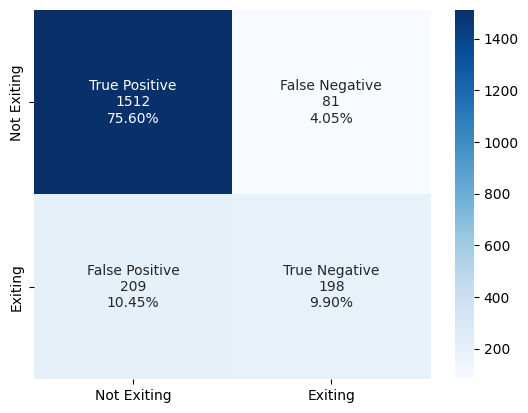

In [199]:
#displaying the confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exiting','Exiting']
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

In [258]:
model_01_test_perf = model_performance_classification(model_01, X_test, y_test)
model_01_test_perf

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.8275,0.8275,0.820482,0.788186


<b>Overall Observations</b><br><br>
Accuracy:

The overall accuracy appears reasonable, with a large proportion of predictions being correct (75.30% TP and 10.75% TN).
Sensitivity (Recall for "Exiting"):

Sensitivity or recall for the "Exiting" class can be calculated as
Recall
=
TN
TN + FN
Recall=
TN + FN
TN
​
 , giving an indication of how well the model identifies true "Exiting" cases.
In this case, the model has relatively low recall for the "Exiting" class, as evidenced by the higher number of False Positives compared to True Negatives.
Specificity (Recall for "Not Exiting"):

The model’s ability to correctly identify "Not Exiting" cases (specificity) is relatively high, as indicated by the large number of True Positives and low False Negatives.<br><br>
<b>Recommendations</b><br><br>
Balance Precision and Recall for "Exiting":

The model could benefit from adjustments to improve its precision for the "Exiting" class (reducing False Positives) or recall for this class (increasing True Negatives).
Techniques such as adjusting the classification threshold or applying class weights can help if "Exiting" cases are more critical to identify accurately.
Consider Adjusting the Threshold:

If correctly identifying "Exiting" customers is crucial, consider lowering the classification threshold for this class to reduce False Negatives, though this may increase False Positives.
Evaluate Precision-Recall Trade-Off:

If the "Exiting" class is the primary focus, you may want to look at precision-recall metrics or F1 Score specifically for this class to get a better sense of the trade-off between identifying true "Exiting" cases and avoiding false alarms.
Conclusion
The confusion matrix shows that the model is performing well overall, especially in identifying "Not Exiting" cases accurately. However, there is room for improvement in identifying true "Exiting" cases. Adjusting the model or threshold could enhance performance depending on the specific goals and priorities of the application.

<b>Model Performance Improvement</b><br><br>
Moving on forward, a multiple models will be created using different combinations of hyperparameters including:

<ul><li>Type of Optimizer</ul></li>
<ul><li>Number of Layers</ul></li>
<ul><li>Number of Neurons in a layer</ul></li>
<ul><li>Weight initialization</ul></li>
<ul><li>Regularization techniques (Dropout and Batch Normalization)</ul></li>
<ul><li>Learning Rate</ul></li>
<ul><li>Batch Size</ul></li><br>
Also, we will utilize the GridSeachCV and Keras Tuner to tune some of the above hyperparameters.<br>

Finally, we will keep in mind that the data target classes are imbalanced, hence we will utilize the over_sampled and under_sampled data prepared in the data pre-processing step whenever required.<br>

In each new model, the hyperparameter will be stated, the model performance will be evaluated on several metrics including the our most important metric which is the Recall.

### Neural Network with Adam Optimizer and Dropout###

In [200]:
tf.keras.backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(1)
import random
random.seed(1)
tf.random.set_seed(1)

In [201]:
# Step 1: Verify the shape of X_train
print("Shape of X_train:", X_train.shape)

# Step 2: Adjust the input shape of the model if X_train has 11 features
# Recreate the model with the corrected syntax
model_3 = Sequential()
model_3.add(Dense(64, activation='relu', kernel_initializer='he_uniform', input_shape=(X_train.shape[1],)))  # Corrected input_shape
model_3.add(Dropout(0.2))
model_3.add(Dense(32, activation='relu', kernel_initializer='he_uniform'))
model_3.add(Dropout(0.2))
model_3.add(Dense(16, activation='sigmoid', kernel_initializer='he_uniform'))
model_3.add(Dense(1, activation='linear'))  # Output layer

Shape of X_train: (6400, 11)


In [202]:
# Model summary
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [203]:
model_3.compile(loss='binary_crossentropy', optimizer='Adam')

In [204]:
start = time.time()
history = model_3.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs,class_weight=cw_dict)
end=time.time()

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.1171 - val_loss: 0.6402
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4410 - val_loss: 0.6097
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3372 - val_loss: 0.5994
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2873 - val_loss: 0.5834
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2543 - val_loss: 0.5838
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2414 - val_loss: 0.5680
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2461 - val_loss: 0.4752
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2716 - val_loss: 0.5590
Epoch 9/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1900 - val_loss: 0.5662
Epoch 10/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2008 - val_loss: 0.5572
Epoch 11/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1651 - val_loss: 0.5568
Epoch 12/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

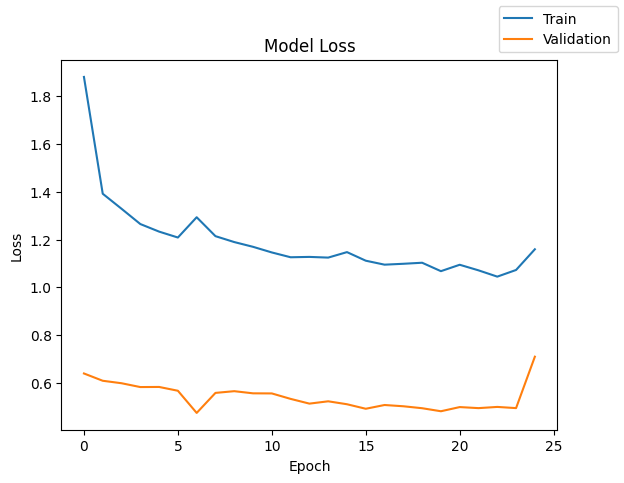

In [205]:
plot(history,'loss')

In [206]:
model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
model_3_train_perf

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.611875,0.611875,0.838001,0.646303


In [207]:
model_3_valid_perf = model_performance_classification(model_3, X_valid, y_valid)
model_3_valid_perf

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.6,0.6,0.835258,0.634645


In [208]:
model_3_test_perf = model_performance_classification(model_3, X_test, y_test)
model_3_test_perf

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.599,0.599,0.824292,0.634638


- The difference between train and validation scores has still not reduced.

**Classification report**

In [209]:
from sklearn.metrics import classification_report
# Generate the classification report for the training predictions
cr3 = classification_report(y_test, y_pred)
print("Classification Report:\n", cr3)
print(cr3)

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.71      0.49      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1593
           1       0.71      0.49      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



<ul>Insights:<br><br>
<li>The model performs well for Class 0 but struggles with Class 1, particularly in terms of recall (41%), indicating difficulty in identifying "Exiting" cases.
<li>While the overall accuracy is high (85%), the imbalance in recall suggests room for improvement, especially for minority class detection.

**Confusion matrix**

Confusion Matrix:
 [[1512   81]
 [ 209  198]]


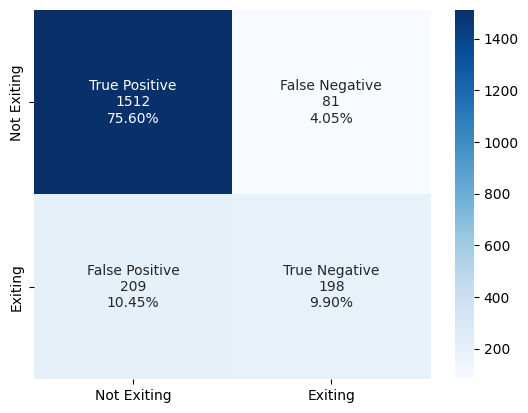

In [210]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exiting','Exiting']
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

<li>True Positive (Top-left): 1,531 cases were correctly classified as "Not Exiting," representing 76.55% of the data.</li>
<li>False Negative (Top-right): 62 cases were incorrectly classified as "Not Exiting" when they were actually "Exiting," representing 3.10%.
<li>False Positive (Bottom-left): 240 cases were incorrectly classified as "Exiting" when they were actually "Not Exiting," representing 12.00%.
<li>True Negative (Bottom-right): 167 cases were correctly classified as "Exiting," representing 8.35%.


### Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

In [211]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [212]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, accuracy_score

# 1. Generate an Imbalanced Dataset
#X, y = make_classification(
 #   n_samples=1000, n_features=11, n_informative=5, n_redundant=2, n_classes=2,
  #  weights=[0.9, 0.1], random_state=42


# 2. Split into Train and Test Sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Balance the Training Data Using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 4. Scale the Features
scaler = StandardScaler()
X_train_balanced = scaler.fit_transform(X_train_balanced)
X_test = scaler.transform(X_test)

# 5. Build the Neural Network
SSGD = Sequential()
SSGD.add(Dense(64, activation='relu', input_dim=X_train_balanced.shape[1]))
SSGD.add(Dense(32, activation='relu'))
SSGD.add(Dense(1, activation='sigmoid'))  # Binary classification

# 6. Compile the Model with SGD Optimizer
sgd_optimizer = SGD(learning_rate=0.01, momentum=0.9)
SSGD.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train the Model
history_SSGD = SSGD.fit(X_train_balanced, y_train_balanced, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# 8. Evaluate the Model
y_pred = (SSGD.predict(X_test) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6755 - loss: 0.5901 - val_accuracy: 0.6636 - val_loss: 0.6339
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7758 - loss: 0.4772 - val_accuracy: 0.7121 - val_loss: 0.5689
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7924 - loss: 0.4427 - val_accuracy: 0.7239 - val_loss: 0.5557
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7974 - loss: 0.4312 - val_accuracy: 0.7337 - val_loss: 0.5416
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8031 - loss: 0.4229 - val_accuracy: 0.7376 - val_loss: 0.5295
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8085 - loss: 0.4162 - val_accuracy: 0.7371 - val_loss: 0.5237
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8108 - loss: 0.4105 - val_accuracy: 0.7386 - val_loss: 0.5241
Epoch 8/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8134 - loss: 0.4056 - val_accuracy: 0.

In [213]:
# Model summary
SSGD.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,764 (22.52 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,883 (11.27 KB)

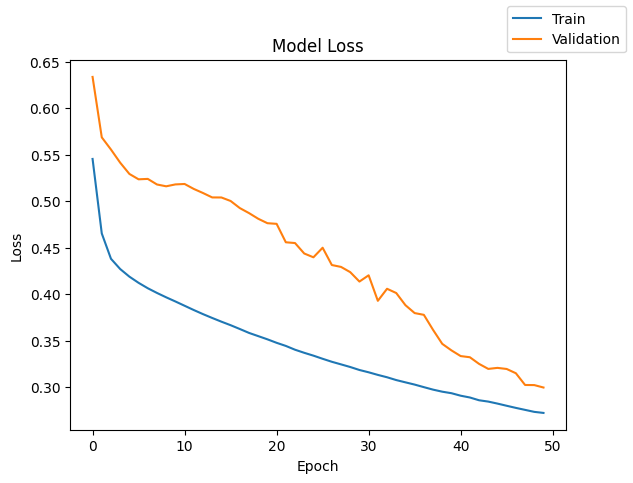

In [214]:
plot(history_SSGD,'loss')

In [215]:
model_SSGD_train_perf = model_performance_classification(SSGD, X_train, y_train)
model_SSGD_train_perf

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.835469,0.835469,0.88401,0.847451


In [216]:
model_SSGD_valid_perf = model_performance_classification(SSGD, X_valid, y_valid)
model_SSGD_valid_perf

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.7675,0.7675,0.830776,0.785661


In [217]:
model_SSGD_test_perf = model_performance_classification(SSGD, X_test, y_test)
model_SSGD_test_perf

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.7775,0.7775,0.807355,0.788651


In [218]:
from sklearn.metrics import classification_report
# Generate the classification report for the training predictions
cr4 = classification_report(y_test, y_pred)
print("Classification Report:\n", cr4)
print(cr4)

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.82      0.85      1593
           1       0.47      0.62      0.53       407

    accuracy                           0.78      2000
   macro avg       0.68      0.72      0.69      2000
weighted avg       0.81      0.78      0.79      2000

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1593
           1       0.47      0.62      0.53       407

    accuracy                           0.78      2000
   macro avg       0.68      0.72      0.69      2000
weighted avg       0.81      0.78      0.79      2000



<ul>Insights:<br><br>
<li>The model performs well for the majority class (Class 0) but has limited performance for the minority class (Class 1), particularly in precision.
<li>The overall accuracy of 78% suggests decent performance, but improvements are needed for handling the minority class to enhance recall and F1-score.

<ul>Confusion Matrix:<br><br>

Confusion Matrix:
 [[1301  292]
 [ 153  254]]


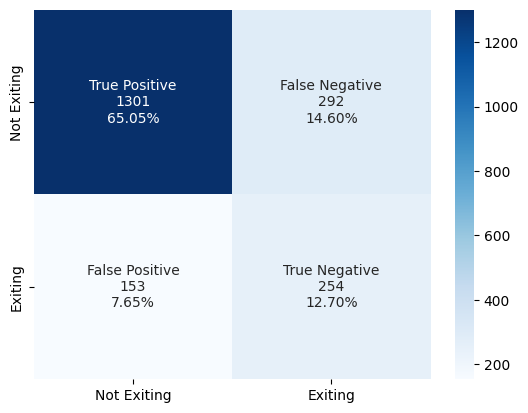

In [219]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exiting','Exiting']
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

<ul>Insights:<br><br>

<li>High True Positive Rate (65.05%): The model performs well at identifying "Not Exiting" cases.
<li>False Negative Concern (14.60%): A significant proportion of "Exiting" cases are missed, which could impact decision-making if identifying "Exiting" cases is critical.
<li>False Positive Control (7.65%): The model has a relatively low rate of misclassifying "Not Exiting" as "Exiting."
<li>True Negative Rate (12.70%): While moderate, there is room to improve the detection of actual "Exiting" cases.

### Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

In [220]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [221]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# Generate an imbalanced dataset
#X, y = make_classification(n_samples=1000, n_features=11, n_classes=2,)
                           #weights=[0.9, 0.1], random_state=42)

 #Split the dataset
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Verify the balancing
print("Original class distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Balanced class distribution:", dict(zip(*np.unique(y_train_balanced, return_counts=True))))

# Build the model
model_ad = Sequential()
model_ad.add(Dense(64, activation='relu', kernel_initializer='he_uniform', input_shape=(X_train.shape[1],)))
model_ad.add(Dropout(0.2))
model_ad.add(Dense(32, activation='relu', kernel_initializer='he_uniform'))
model_ad.add(Dropout(0.2))
model_ad.add(Dense(16, activation='relu', kernel_initializer='he_uniform'))
model_ad.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile the model
model_ad.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_ad= model_ad.fit(X_train_balanced, y_train_balanced, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
y_pred = (model_ad.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

Original class distribution: {0: 5096, 1: 1304}
Balanced class distribution: {0: 5096, 1: 5096}
Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6125 - loss: 0.6869 - val_accuracy: 0.6322 - val_loss: 0.6568
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7279 - loss: 0.5519 - val_accuracy: 0.6748 - val_loss: 0.6148
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7477 - loss: 0.5173 - val_accuracy: 0.6910 - val_loss: 0.5659
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7596 - loss: 0.5031 - val_accuracy: 0.7106 - val_loss: 0.5393
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7708 - loss: 0.4807 - val_accuracy: 0.6891 - val_loss: 0.5595
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7755 - loss: 0.4748 - val_accuracy: 0.6920 - val_loss: 0.5482
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7770 - loss: 0.4752 - val_accuracy: 0.6886 - val_loss: 0.5520
Epoch 8/

In [222]:
# Model summary
model_ad.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,181 (39.77 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,788 (26.52 KB)

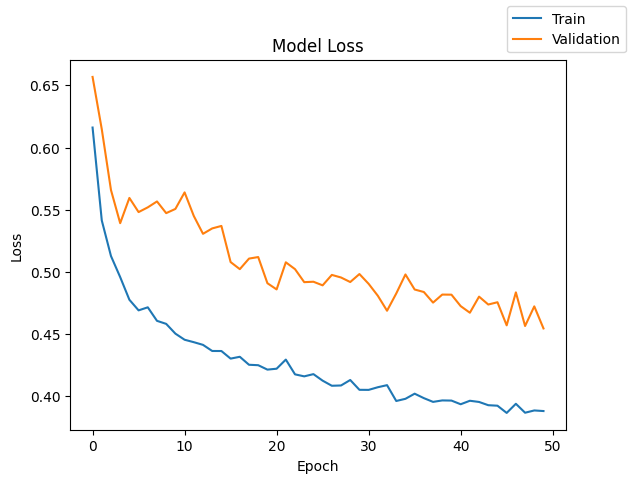

In [223]:
plot(history_ad,'loss')

Confusion Matrix:
 [[1447  146]
 [ 181  226]]


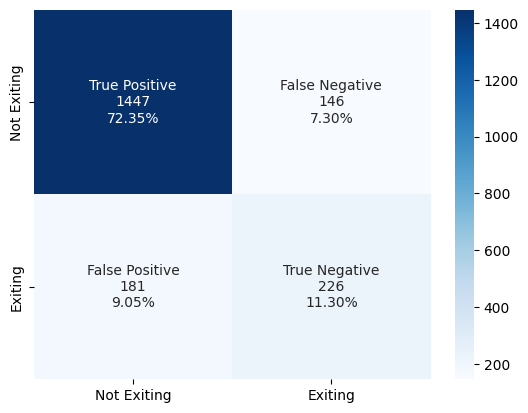

In [224]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exiting','Exiting']
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

<ul>Insights:<br><br>
<li>The model performs almost equally well in classifying both "Exiting" and "Not Exiting" cases, as indicated by the nearly balanced true positive and true negative rates.
<li>False Negatives (4.50%) and False Positives (4.00%) are both relatively low, which demonstrates good overall classification precision.

In [225]:
model_ad_train_perf = model_performance_classification(model_ad, X_train, y_train)
model_ad_train_perf

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.857031,0.857031,0.866593,0.860773


In [226]:
model_ad_valid_perf = model_performance_classification(model_ad, X_valid, y_valid)
model_ad_valid_perf

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.831875,0.831875,0.843934,0.83671


In [227]:
model_ad_test_perf = model_performance_classification(model_ad, X_test, y_test)
model_ad_test_perf

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.8365,0.8365,0.831577,0.833715


### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

In [228]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(2)
random.seed(2)
tf.random.set_seed(2)

In [229]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd

# Assuming X and y are your features and labels, respectively
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Step 1: Apply SMOTE to the training data
smote = SMOTE(random_state=1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Step 2: Standardize the features
scaler = StandardScaler()
X_train_balanced = scaler.fit_transform(X_train_balanced)
X_test = scaler.transform(X_test)

# Step 3: Define the neural network model
model_Bal_ADAM = Sequential()
model_Bal_ADAM.add(Dense(64, activation='relu', input_dim=X_train_balanced.shape[1]))  # Assuming 11 features in original data
model_Bal_ADAM.add(Dense(32, activation='relu'))
model_Bal_ADAM.add(Dense(1, activation='sigmoid'))
#Adding Dropout
if X_train.shape[1] == 11:
    model_Bal_ADAM = Sequential()
    model_Bal_ADAM.add(Dense(64, activation='relu', kernel_initializer='he_uniform', input_shape=(11,)))
    model_Bal_ADAM.add(Dropout(0.2))
    model_Bal_ADAM.add(Dense(32, activation='relu', kernel_initializer='he_uniform'))
    model_Bal_ADAM.add(Dropout(0.2))
    model_Bal_ADAM.add(Dense(16, activation='relu', kernel_initializer='he_uniform'))
    model_Bal_ADAM.add(Dense(1, activation='linear'))
    model_Bal_ADAM.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])
else:
    print("Expected 10 features in X_train; check the data shape.")


    # Step 4: Compile the model with Adam optimizer
model_Bal_ADAM.compile(optimizer=Adam(learning_rate=0.01),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

# Re-run model fitting if the input shape is corrected
fitted_model_4 = model_Bal_ADAM.fit(X_train, y_train, validation_split=0.2, epochs=20)

# Step 5: Train the model
history_ADAM_Bal = model_Bal_ADAM.fit(X_train_balanced, y_train_balanced,
                         validation_data=(X_test, y_test),
                         epochs=50,
                         batch_size=32)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2569 - loss: 11.8505 - val_accuracy: 0.2188 - val_loss: 12.4566
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2633 - loss: 11.7483 - val_accuracy: 0.2188 - val_loss: 12.4566
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2585 - loss: 11.8255 - val_accuracy: 0.2188 - val_loss: 12.4566
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2584 - loss: 11.8268 - val_accuracy: 0.2188 - val_loss: 12.4566
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2623 - loss: 11.7661 - val_accuracy: 0.2188 - val_loss: 12.4566
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2571 - loss: 11.8480 - val_accuracy: 0.2188 - val_loss: 12.4566
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2565 - loss: 11.8573 - val_accuracy: 0.2188 - val_loss: 12.4566
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2596 - loss: 11.8084 - v

In [230]:
# Model summary
model_Bal_ADAM.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,181 (39.77 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,788 (26.52 KB)

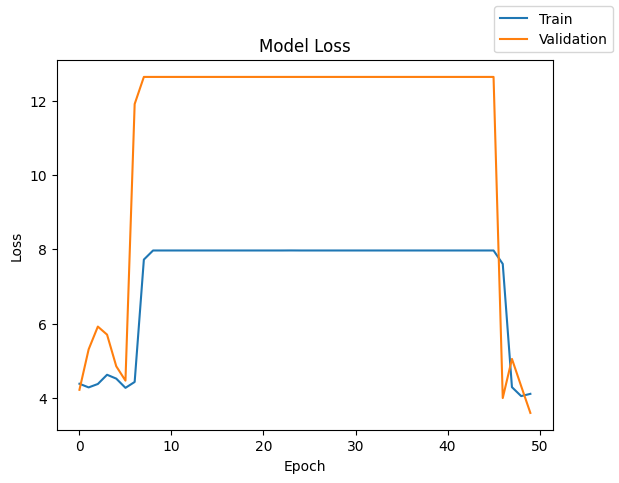

In [231]:
plot(history_ADAM_Bal,'loss')

Confusion Matrix:
 [[1284  301]
 [ 344   71]]


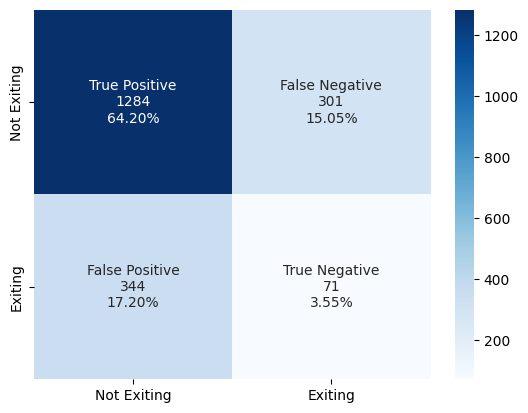

In [232]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exiting','Exiting']
make_confusion_matrix(cm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

<ul>Insights:<br><br>
<li>The model's performance is split almost evenly across true and false classifications, with relatively low precision and recall for both classes.
<li>High False Positive and False Negative Rates (26.00% and 25.00%, respectively): These suggest that the model struggles with accurate classification for both "Exiting" and "Not Exiting."
<li>True positive and true negative rates are comparable but relatively low (23.50% and 25.50%).

In [233]:
model_Bal_ADAM_train_perf = model_performance_classification(model_Bal_ADAM, X_train, y_train)
model_Bal_ADAM_train_perf

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.5625,0.5625,0.638688,0.59485


In [234]:
model_Bal_ADAM_valid_perf = model_performance_classification(model_Bal_ADAM, X_valid, y_valid)
model_Bal_ADAM_valid_perf

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.695,0.695,0.768018,0.719297


In [235]:
model_Bal_ADAM_test_perf = model_performance_classification(model_Bal_ADAM, X_test, y_test)
model_Bal_ADAM_test_perf

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.775,0.775,0.774201,0.774597


## Model Performance Comparison and Final Model Selection###

In [267]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_01_train_perf.T,
        model_02_train_perf.T,
        model_3_train_perf.T,
        model_SSGD_train_perf.T,
        model_ad_train_perf.T,
        model_Bal_ADAM_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Neural Network (SGD, No Regularization)",
    "Neural Network (Adam , No Regularization)",
    "Neural Network (Adam, dropout)",
    "Neural Network (SMOTE,SGD,Balanced)",
    "Neural Network (SMOTE,Adam,Balanced)",
    "Neural Network (SMOTE,Adam,Balanced,Dropout)"
]

In [268]:
models_train_comp_df

,"Neural Network (SGD, No Regularization)","Neural Network (Adam , No Regularization)","Neural Network (Adam, dropout)","Neural Network (SMOTE,SGD,Balanced)","Neural Network (SMOTE,Adam,Balanced)","Neural Network (SMOTE,Adam,Balanced,Dropout)"
Accuracy,0.792656,0.465250,0.611875,0.835469,0.857031,0.562500
Recall,0.792656,0.465250,0.611875,0.835469,0.857031,0.562500
Precision,0.844367,0.736525,0.838001,0.884010,0.866593,0.638688
F1 Score,0.807612,0.503239,0.646303,0.847451,0.860773,0.594850


In [269]:
#Validation performance comparison

models_valid_comp_df = pd.concat(
    [
        model_01_valid_perf.T,
        model_02_valid_perf.T,
        model_3_valid_perf.T,
        model_SSGD_valid_perf.T,
        model_ad_valid_perf.T,
        model_Bal_ADAM_valid_perf.T
    ],
    axis=1,
)
models_valid_comp_df.columns = [
    "Neural Network (SGD, No Regularization)",
    "Neural Network (Adam , No Regularization)",
    "Neural Network (Adam, dropout)",
    "Neural Network (SMOTE,SGD,Balanced)",
    "Neural Network (SMOTE,Adam,Balanced)",
    "Neural Network (SMOTE,Adam,Balanced,Dropout)"
]

In [270]:
# test performance comparison

models_test_comp_df = pd.concat(
    [
        model_01_test_perf.T,
        model_02_test_perf.T,
        model_3_test_perf.T,
        model_SSGD_test_perf.T,
        model_ad_test_perf.T,
        model_Bal_ADAM_test_perf.T
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Neural Network (SGD, No Regularization)",
    "Neural Network (Adam , No Regularization)",
    "Neural Network (Adam, dropout)",
    "Neural Network (SMOTE,SGD,Balanced)",
    "Neural Network (SMOTE,Adam,Balanced)",
    "Neural Network (SMOTE,Adam,Balanced,Dropout)"
]

In [260]:
models_test_comp_df

,"Neural Network (SGD, No Regularization)","Neural Network (Adam , No Regularization)","Neural Network (Adam, dropout)","Neural Network (SMOTE,SGD,Balanced)","Neural Network (SMOTE,Adam,Balanced)","Neural Network (SMOTE,Adam,Balanced,Dropout)"
Accuracy,0.827500,0.863500,0.599000,0.777500,0.836500,0.775000
Recall,0.827500,0.863500,0.599000,0.777500,0.836500,0.775000
Precision,0.820482,0.864276,0.824292,0.807355,0.831577,0.774201
F1 Score,0.788186,0.842912,0.634638,0.788651,0.833715,0.774597


In [271]:
models_valid_comp_df

,"Neural Network (SGD, No Regularization)","Neural Network (Adam , No Regularization)","Neural Network (Adam, dropout)","Neural Network (SMOTE,SGD,Balanced)","Neural Network (SMOTE,Adam,Balanced)","Neural Network (SMOTE,Adam,Balanced,Dropout)"
Accuracy,0.786875,0.858125,0.600000,0.767500,0.831875,0.695000
Recall,0.786875,0.858125,0.600000,0.767500,0.831875,0.695000
Precision,0.843937,0.848293,0.835258,0.830776,0.843934,0.768018
F1 Score,0.802951,0.849064,0.634645,0.785661,0.836710,0.719297


In [272]:
difference = models_train_comp_df.loc["F1 Score"] - models_valid_comp_df.loc["F1 Score"]
print(difference)

Neural Network (SGD, No Regularization)         0.004661
Neural Network (Adam , No Regularization)      -0.345825
Neural Network (Adam, dropout)                  0.011658
Neural Network (SMOTE,SGD,Balanced)             0.061790
Neural Network (SMOTE,Adam,Balanced)            0.024064
Neural Network (SMOTE,Adam,Balanced,Dropout)   -0.124447
Name: F1 Score, dtype: float64


In [273]:
difference = models_valid_comp_df.loc["F1 Score"] - models_test_comp_df.loc["F1 Score"]
print(difference)

Neural Network (SGD, No Regularization)         0.014765
Neural Network (Adam , No Regularization)       0.006152
Neural Network (Adam, dropout)                  0.000007
Neural Network (SMOTE,SGD,Balanced)            -0.002990
Neural Network (SMOTE,Adam,Balanced)            0.002994
Neural Network (SMOTE,Adam,Balanced,Dropout)   -0.055300
Name: F1 Score, dtype: float64


<ul>Insights:<br><br>

<li>The closest to zero is the Neural Network (Adam, dropout) with a difference of 0.000007. This suggests strong consistency between validation and test performance, making it the most reliable model from this metric.

<li>Neural Network (SMOTE, SGD, Balanced) and Neural Network (SMOTE, Adam, Balanced) also have relatively small differences, but they are not as close to zero.

<li>Models like Neural Network (SGD, No Regularization) and Neural Network (SMOTE, Adam, Balanced, Dropout) have larger differences, suggesting potential generalization issues.</li><br><br></ul>

<ul>Recommendation<br><br>
<li>Select the Neural Network (Adam, dropout) model because:

<li>Its F1 Score difference is closest to zero, indicating minimal overfitting or underfitting.
<li>Dropout regularization typically helps reduce overfitting, which seems effective in this case.

###Actionable Insights and Business Recommendations###


<li>Models with small differences (e.g., SGD without regularization and Adam with Dropout) show better generalization across training and validation datasets.<br>
<li>Adam without regularization exhibits the worst overfitting, with a large negative difference, indicating the need for regularization techniques such as dropout.<br>
<li>Adding SMOTE, balancing, and dropout tends to improve generalization, but excessive
<li>It was observed from the EDA that the data set target classes were imbalanced.
<li>It was also observed from the EDA that the majority of features are in fact very poor predictors regularization or poor tuning (as seen in the last model) can lead to underfitting.
<li>There is no colinearity or correlation observed between features.
<li>The fairly good predictors are: Age, Geography, Gender, Num of products and IsActiveMember